Model fitting 2: SSC + galaxy template
======================================


In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs


In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
data=Data.from_file(test_SEDs[3])



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



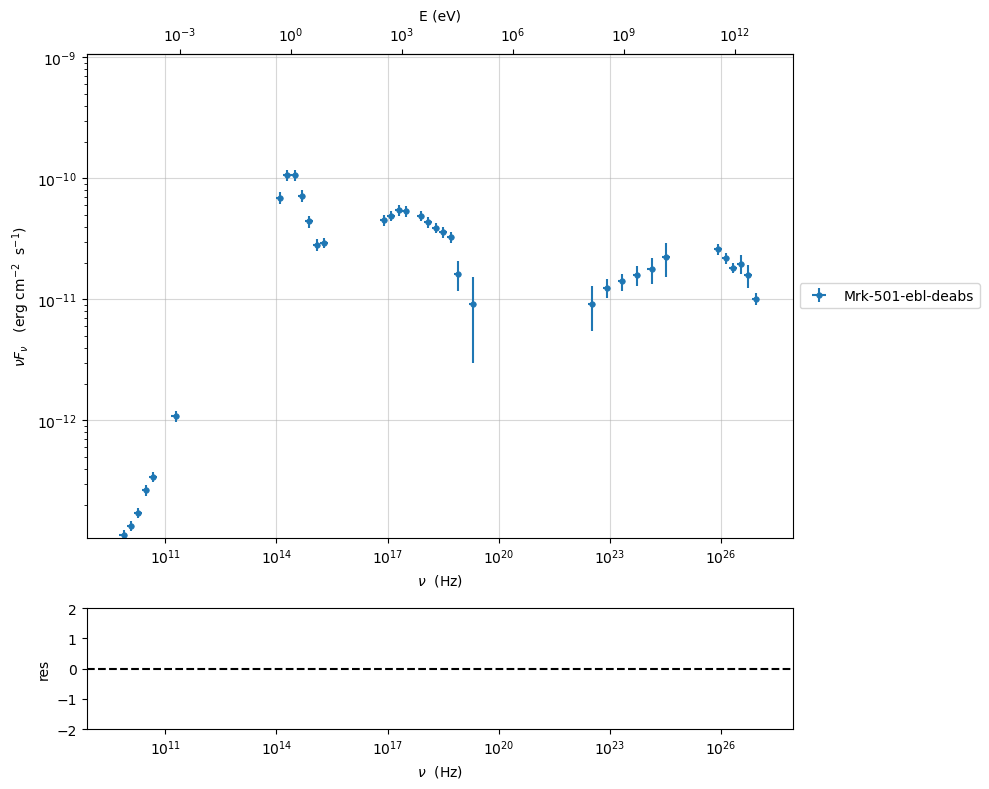

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()

In [6]:
sed_data.save('Mrk_501.pkl')

## Phenomenological model constraining

### Spectral indices


*** evaluating spectral indices for data ***



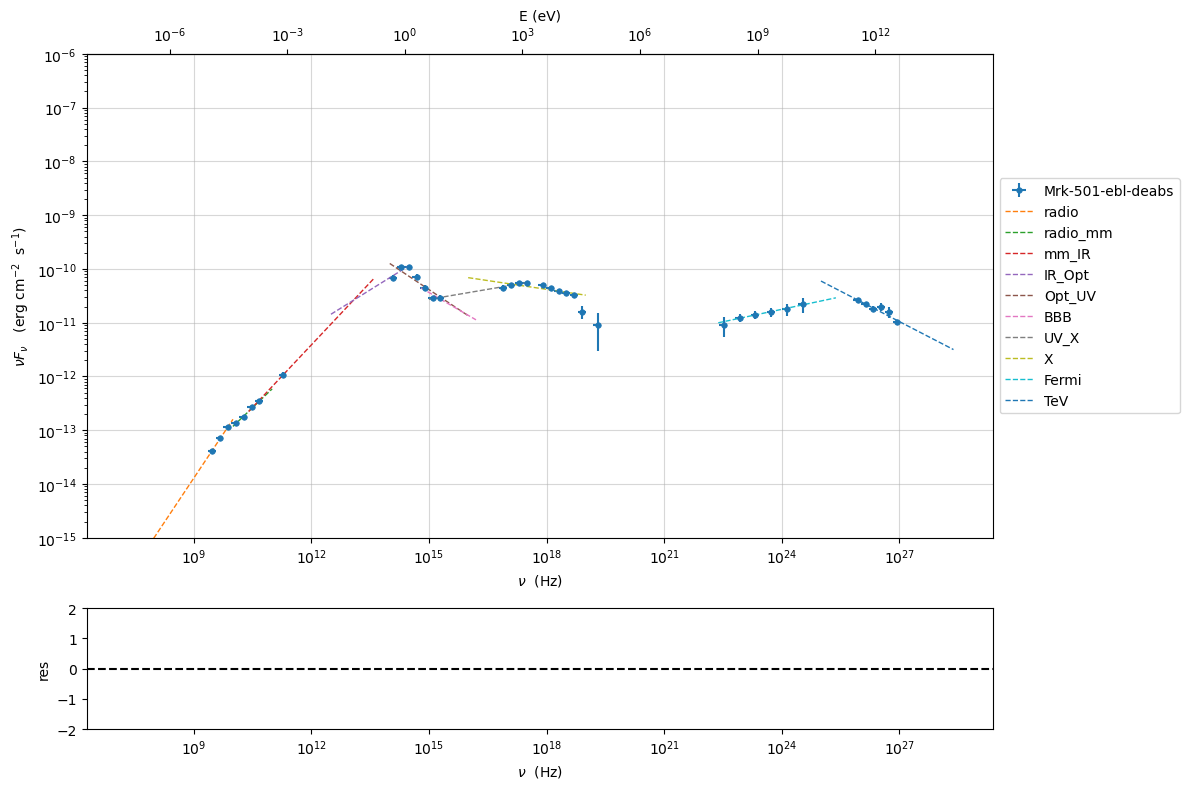

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=1E-6)

### Sed shaper

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=True,
  Ep_start=None,
  minimizer='lsb',
  silent=True,
  fit_range=[10. , 21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP

---> class:  HSP




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-5.589204e-02,-5.589204e-02,6.234641e-03,--,-5.237376e-02,-1.000000e+01,0.000000e+00,False
LogCubic,c,-3.292704e-04,-3.292704e-04,8.968206e-04,--,7.639964e-03,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.698160e+01,1.698160e+01,8.583094e-02,--,1.556163e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.030620e+01,-1.030620e+01,1.607997e-02,--,-1.019011e+01,-3.000000e+01,0.000000e+00,False
host_galaxy,nuFnu_p_host,-9.972939e+00,-9.972939e+00,3.177593e-02,--,-1.019011e+01,-1.219011e+01,-8.190114e+00,False
host_galaxy,nu_scale,-2.290459e-03,-2.290459e-03,1.811408e-03,--,0.000000e+00,-2.908697e-03,2.908697e-03,False


---> sync       nu_p=+1.698160e+01 (err=+8.583094e-02)  nuFnu_p=-1.030620e+01 (err=+1.607997e-02) curv.=-5.589204e-02 (err=+6.234641e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.353504e-01,-1.353504e-01,3.124219e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-3.471531e-02,-3.471531e-02,2.003374e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.545984e+01,2.545984e+01,2.139886e-01,--,2.550130e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.057347e+01,-1.057347e+01,4.194508e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.545984e+01 (err=+2.139886e-01)  nuFnu_p=-1.057347e+01 (err=+4.194508e-02) curv.=-1.353504e-01 (err=+3.124219e-02)



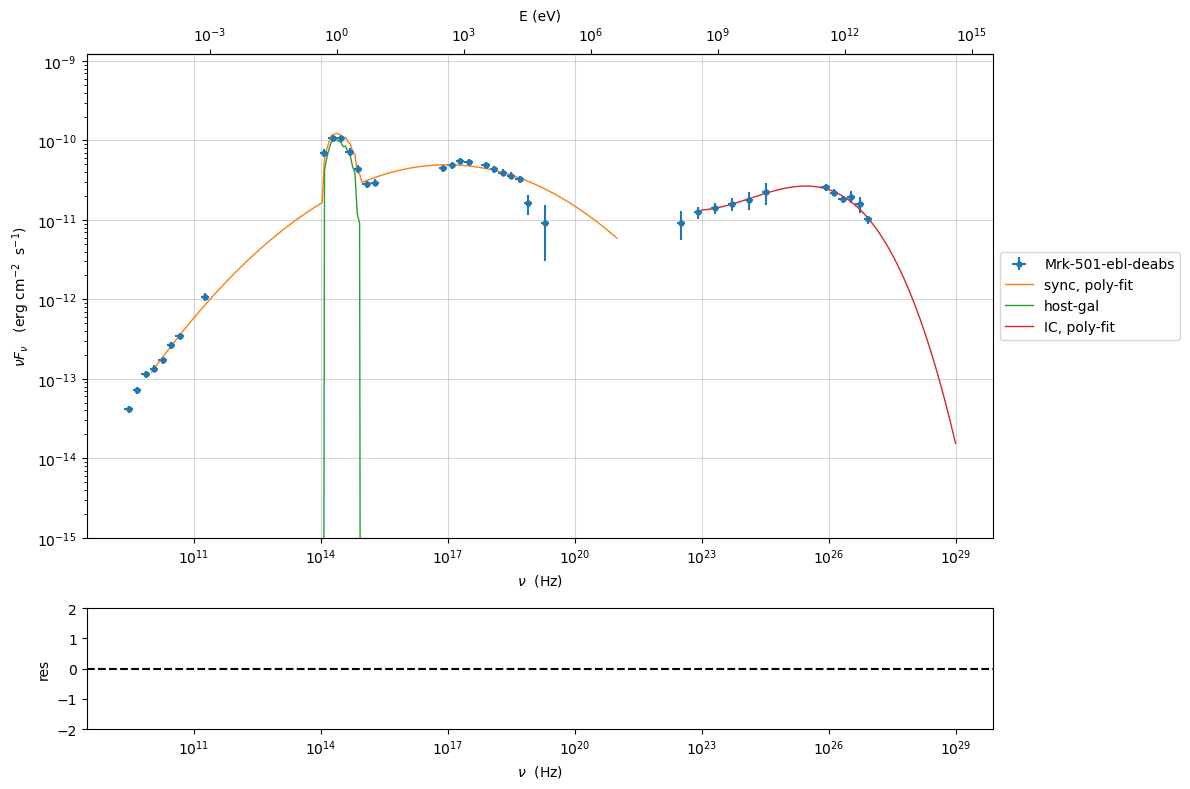

In [9]:
my_shape.IC_fit(fit_range=[23., 29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [10]:
from jetset.obs_constrain import ObsConstrain
from jetset.model_manager import  FitModel
from jetset.minimizer import fit_SED
sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        distr_e='lppl',
                        t_var_sec=3*86400,
                        nu_cut_IR=1E11,
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet_gal_templ.pkl')


***  constrains parameters from observable ***



/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/obs_constrain.py:1514: RankWarning: Polyfit may be poorly conditioned
  p=polyfit(nu_p_IC_model_log,B_grid_log,2)


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.208522e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.050000e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.360000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.487509e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,2.121873e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,2.415254e+01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,6.673207e+03,1.000000e+00,1.000000e+09,False,False


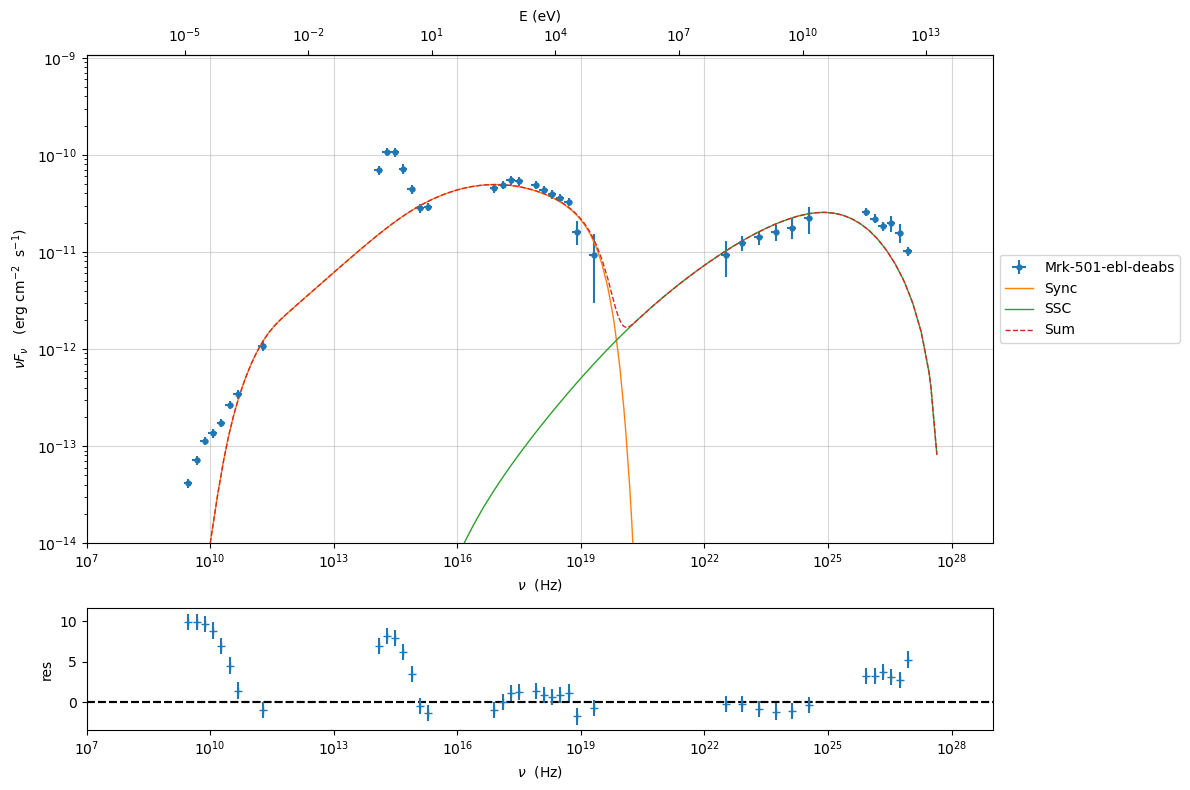

In [11]:
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-14,x_min=1E7,x_max=1E29)

## Model fitting procedure

### Model fitting with LSB

In [12]:
from jetset.model_manager import  FitModel
from jetset.jet_model import Jet

jet=Jet.load_model('prefit_jet_gal_templ.pkl')
jet.set_gamma_grid_size(200)

In [13]:
fit_model=FitModel( jet=jet, name='SSC-best-fit-lsb',template=my_shape.host_gal) 
fit_model.show_model()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: SSC-best-fit-lsb  
type: composite_model  
components models:
 -model name: jet_leptonic model type: jet
 -model name: host_galaxy model type: template

--------------------------------------------------------------------------------
individual component description

--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  
geometry: spherical  

electrons distribution:
 type: lppl  
 gamma energy grid size:  201
 gmin grid : 1.487509e+02
 gmax grid : 2.121873e+06
 normalization:  True
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e+00

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.487509e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,2.121873e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,2.415254e+01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,6.673207e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,s,LE_spectral_slope,,2.251647e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,r,spectral_curvature,,2.794602e-01,-1.500000e+01,1.500000e+01,False,False
jet_leptonic,R,region_size,cm,1.208522e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,5.050000e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True


--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
model description
--------------------------------------------------------------------------------
name: host_galaxy  
type: template  

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
host_galaxy,nuFnu_p_host,nuFnu-scale,erg / (s cm2),-9.972939e+00,-2.000000e+01,2.000000e+01,False,False
host_galaxy,nu_scale,nu-scale,Hz,-2.290459e-03,-2.000000e+00,2.000000e+00,False,False


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


In [14]:
fit_model.composite_expr='jet_leptonic + host_galaxy'

In [15]:
fit_model.freeze('jet_leptonic','z_cosm')
fit_model.freeze('jet_leptonic','R_H')
fit_model.jet_leptonic.parameters.N.fit_range=[1E-5, 1E5]
fit_model.jet_leptonic.parameters.B.fit_range=[1E-3, 1]

fit_model.jet_leptonic.parameters.beam_obj.fit_range=[5., 50.]
fit_model.jet_leptonic.parameters.R.fit_range=[1E15,1E17]
fit_model.jet_leptonic.parameters.gmax.fit_range=[1E4,1E8]
fit_model.host_galaxy.parameters.nuFnu_p_host.frozen=False
fit_model.host_galaxy.parameters.nu_scale.frozen=True

In [16]:
from jetset.minimizer import fit_SED,ModelMinimizer

model_minimizer_lsb=ModelMinimizer('lsb')
best_fit_lsb=model_minimizer_lsb.fit(fit_model,sed_data,1E11,1E29,fitname='SSC-best-fit-lsb',repeat=1)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 31

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=4.28400e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-lsb


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.172236e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,2.121872e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,3.419590e+01,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,8.709021e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,s,LE_spectral_slope,,2.219322e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,r,spectral_curvature,,2.635538e-01,-1.500000e+01,1.500000e+01,False,False
jet_leptonic,R,region_size,cm,1.208522e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,3.781473e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True



converged=True
calls=371
mesg=


'`ftol` termination condition is satisfied.'

dof=21
chisq=42.839982, chisq/red=2.039999 null hypothesis sig=0.003295

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
jet_leptonic,gmin,1.172236e+02,1.172236e+02,2.853563e+02,--,1.487509e+02,1.000000e+00,1.000000e+09,False
jet_leptonic,gmax,2.121872e+06,2.121872e+06,2.926648e+06,--,2.121873e+06,1.000000e+04,1.000000e+08,False
jet_leptonic,N,3.419590e+01,3.419590e+01,2.318074e+02,--,2.415254e+01,1.000000e-05,1.000000e+05,False
jet_leptonic,gamma0_log_parab,8.709021e+03,8.709021e+03,1.367815e+04,--,6.673207e+03,1.000000e+00,1.000000e+09,False
jet_leptonic,s,2.219322e+00,2.219322e+00,1.015618e-01,--,2.251647e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,r,2.635538e-01,2.635538e-01,6.585091e-02,--,2.794602e-01,-1.500000e+01,1.500000e+01,False
jet_leptonic,R,1.208522e+16,1.208522e+16,4.645662e+16,--,1.208522e+16,1.000000e+15,1.000000e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,3.781473e-02,3.781473e-02,6.252418e-02,--,5.050000e-02,1.000000e-03,1.000000e+00,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


-------------------------------------------------------------------------




In [17]:
best_fit_lsb.save_report('SSC-best-fit-lsb.pkl')
model_minimizer_lsb.save_model('model_minimizer_lsb.pkl')
fit_model.save_model('fit_model_lsb.pkl')

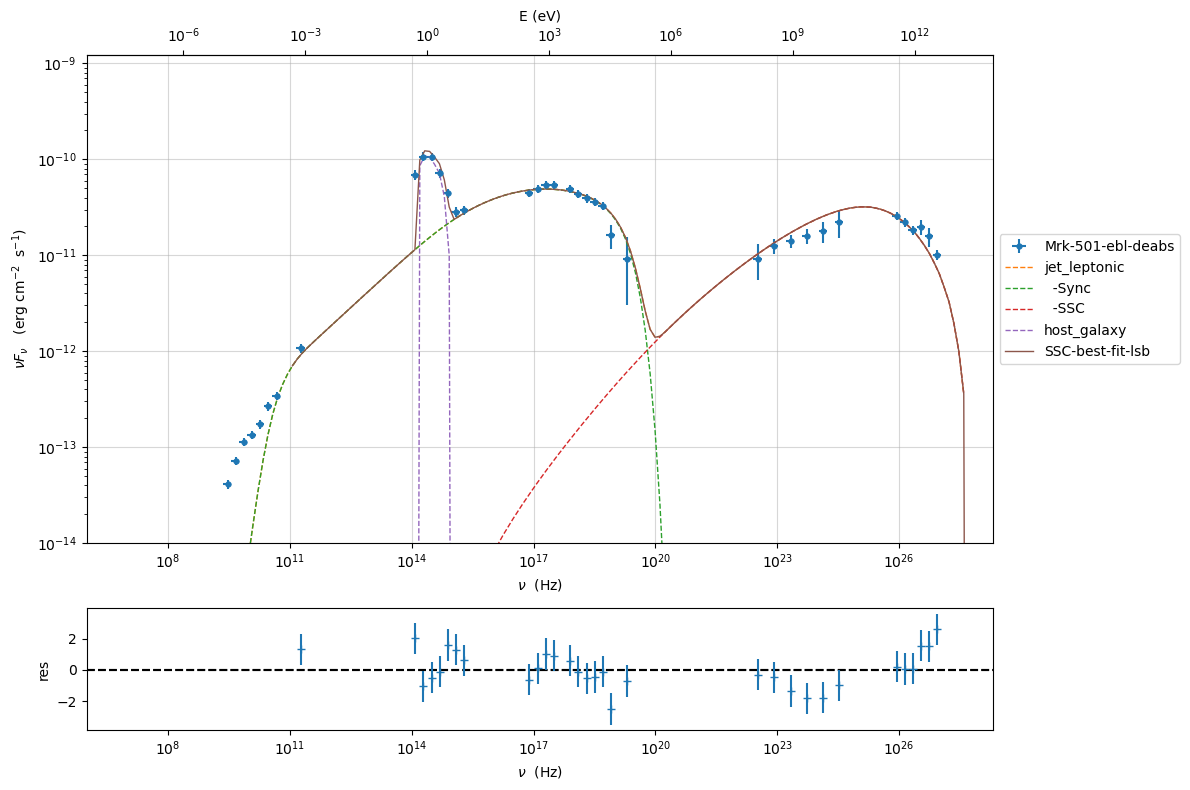

In [18]:
%matplotlib inline
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### Model fitting with Minuit

To run the ``minuit`` minimizer we will use the best-fit results from ``lsb`` to set the boundaries for our parameters. 

In [19]:
fit_model.freeze('jet_leptonic','z_cosm')
fit_model.freeze('jet_leptonic','R_H')
fit_model.jet_leptonic.parameters.beam_obj.fit_range=[5., 50.]
fit_model.jet_leptonic.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model.host_galaxy.parameters.nuFnu_p_host.frozen=False
fit_model.host_galaxy.parameters.nu_scale.frozen=True
fit_model.jet_leptonic.parameters.gmin.fit_range=[10,1000]
fit_model.jet_leptonic.parameters.gmax.fit_range=[5E5,1E8]
fit_model.jet_leptonic.parameters.gamma0_log_parab.fit_range=[1E3,5E5]



In [20]:
model_minimizer_minuit=ModelMinimizer('minuit')
best_fit_minuit=model_minimizer_minuit.fit(fit_model,sed_data,1E11,1E29,fitname='SSC-best-fit-minuit',repeat=3)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 31

*** start fit process ***
----- 
fit run: 0


0it [00:00, ?it/s]

- best chisq=1.37582e+01

fit run: 1
- old chisq=1.37582e+01


0it [00:00, ?it/s]

- best chisq=1.36471e+01

fit run: 2
- old chisq=1.36471e+01


...


converged=True
calls=5060
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 13.64                      │             Nfcn = 5060              │
│ EDM = 0.247 (Goal: 0.0002)       │            time = 6.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0 │    90     │     7     │            │            │   10    │  1000   │       │
│ 1 │ par_1 │  2.49e6   │  0.05e6   │            │            │ 500000  │  1e+08  │       │
│ 2 │ par_2 │   7.47    │   0.22    │            │            │  1e-05  │ 100000  │       │
│ 3 │ par_3 │  1.03e3   │  0.06e3   │            │            │  1000   │ 500000  │       │
│ 4 │ par_4 │   1.993   │   0.013   │            │            │   -10   │   10    │       │
│ 5 │ par_5 │   0.183   │   0.006   │            │            │   -15   │   15    │       │
│ 6 │ par_6 │  31.9e15  │  0.8e15   │            │            │3.16228e+15│3.16228e+17│       │
│ 7 │ par_7 │  9.2e-3   │  0.4e-3   │            │            │  0.001  │    1    │       │
│ 8 │ par_8 │   34.3    │    0.4    │            │            │    5    │   50    │       │
│ 9 │ par_9 │  -9.967   │   0.022   │            │            │-12.1901 │-8.19011 │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=21
chisq=13.641061, chisq/red=0.649574 null hypothesis sig=0.884518

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
jet_leptonic,gmin,9.033414e+01,9.033414e+01,7.338552e+00,--,1.172236e+02,1.000000e+01,1.000000e+03,False
jet_leptonic,gmax,2.489652e+06,2.489652e+06,4.525832e+04,--,2.121872e+06,5.000000e+05,1.000000e+08,False
jet_leptonic,N,7.466404e+00,7.466404e+00,2.226567e-01,--,3.419590e+01,1.000000e-05,1.000000e+05,False
jet_leptonic,gamma0_log_parab,1.025100e+03,1.025100e+03,5.880384e+01,--,8.709021e+03,1.000000e+03,5.000000e+05,False
jet_leptonic,s,1.992998e+00,1.992998e+00,1.316877e-02,--,2.219322e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,r,1.830227e-01,1.830227e-01,6.017357e-03,--,2.635538e-01,-1.500000e+01,1.500000e+01,False
jet_leptonic,R,3.192345e+16,3.192345e+16,7.958194e+14,--,1.208522e+16,3.162278e+15,3.162278e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,9.197306e-03,9.197306e-03,3.999634e-04,--,3.781473e-02,1.000000e-03,1.000000e+00,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


-------------------------------------------------------------------------




for further information regardin minuit please refer to https://iminuit.readthedocs.io/en/stable/

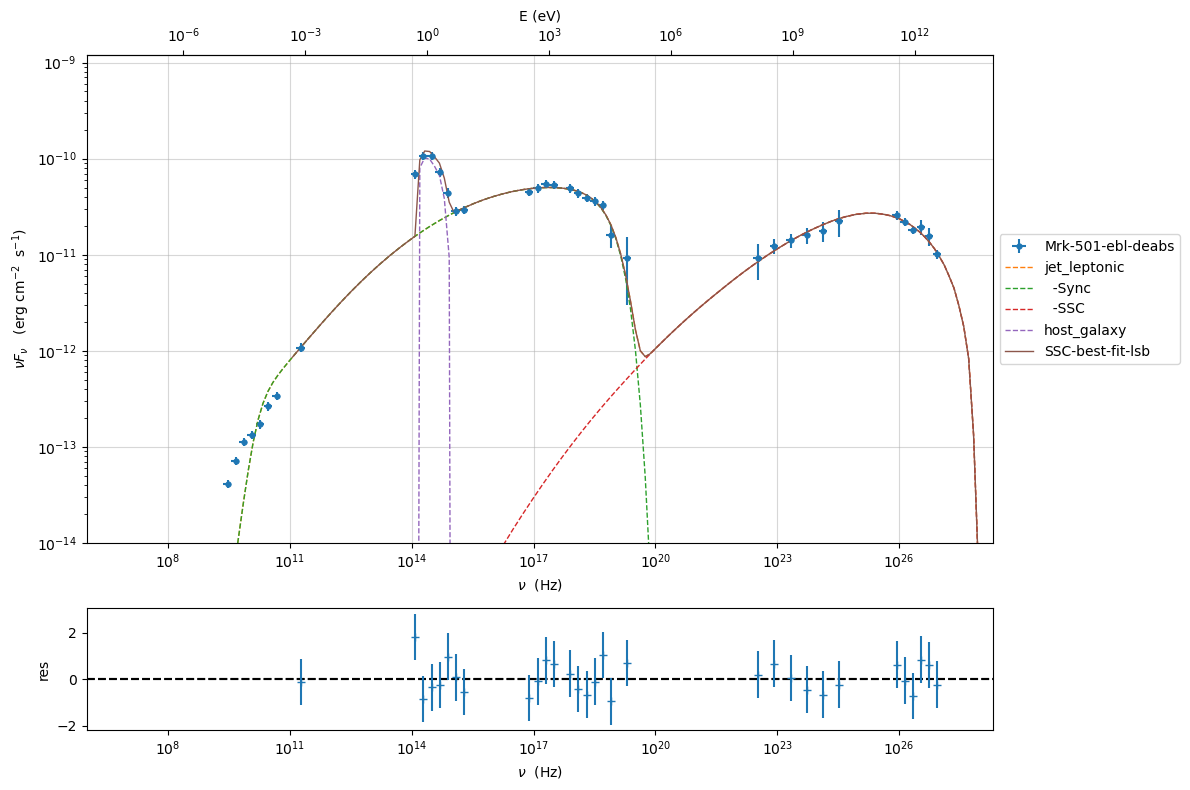

In [21]:
%matplotlib inline
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

In [22]:
best_fit_minuit.save_report('SSC-best-fit-minuit.pkl')
model_minimizer_minuit.save_model('model_minimizer_minuit.pkl')
fit_model.save_model('fit_model_minuit.pkl')

### Model fitting with a bkn pl


In [23]:
from jetset.obs_constrain import ObsConstrain
from jetset.model_manager import  FitModel
from jetset.minimizer import fit_SED
sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        distr_e='bkn',
                        t_var_sec=3*86400,
                        nu_cut_IR=1E11,
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet_bkn_gal_templ.pkl')


***  constrains parameters from observable ***



model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.156554e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,3.158426e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.360000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.880919e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,2.683055e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.695657e+01,0.000000e+00,--,False,False
jet_leptonic,gamma_break,turn-over-energy,lorentz-factor*,1.841500e+05,1.000000e+00,1.000000e+09,False,False


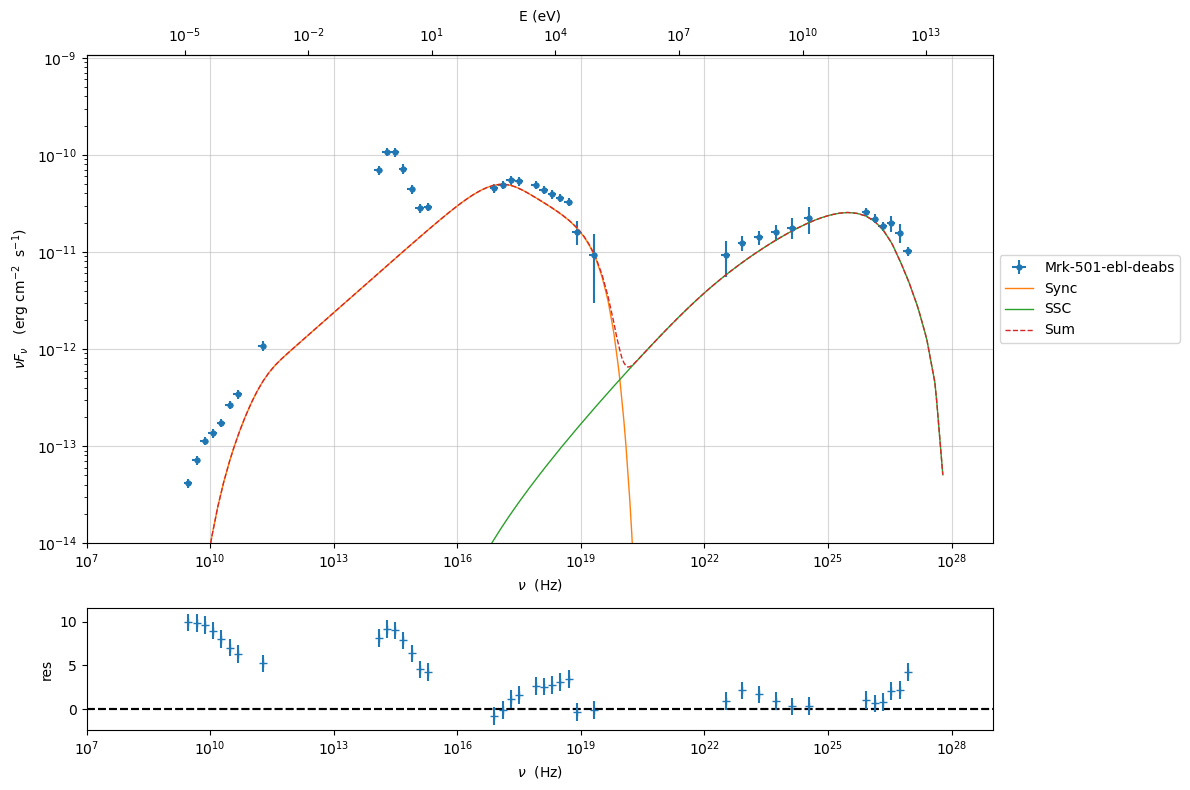

In [24]:
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-14,x_min=1E7,x_max=1E29)

In [25]:
jet_minuit_bkn=Jet.load_model('prefit_jet_bkn_gal_templ.pkl')
jet_minuit_bkn.set_gamma_grid_size(200)

fit_model_bkn=FitModel( jet=jet_minuit_bkn, name='SSC-best-fit-bkn-lsb',template=my_shape.host_gal) 


fit_model_bkn.freeze('jet_leptonic','z_cosm')
fit_model_bkn.freeze('jet_leptonic','R_H')
fit_model_bkn.jet_leptonic.parameters.beam_obj.fit_range=[5,50]
fit_model_bkn.jet_leptonic.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model_bkn.jet_leptonic.parameters.gmax.fit_range=[1E4,1E8]
fit_model_bkn.host_galaxy.parameters.nuFnu_p_host.frozen=False
fit_model_bkn.host_galaxy.parameters.nu_scale.frozen=True



In [26]:
model_minimizer_lsb_bkn=ModelMinimizer('lsb')
best_fit_lsb_bkn=model_minimizer_lsb_bkn.fit(fit_model_bkn,sed_data,1E11,1E29,fitname='SSC-best-fit-lsb')


filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 31

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=1.51898e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-lsb


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.293600e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.624709e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.011791e+01,0.000000e+00,--,False,False
jet_leptonic,gamma_break,turn-over-energy,lorentz-factor*,6.552381e+04,1.000000e+00,1.000000e+09,False,False
jet_leptonic,p,LE_spectral_slope,,2.401467e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,p_1,HE_spectral_slope,,2.970469e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.157161e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.298148e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True



converged=True
calls=791
mesg=


'`ftol` termination condition is satisfied.'

dof=21
chisq=15.189772, chisq/red=0.723322 null hypothesis sig=0.813311

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
jet_leptonic,gmin,3.293600e+02,3.293600e+02,3.982487e+02,--,1.880919e+02,1.000000e+00,1.000000e+09,False
jet_leptonic,gmax,1.624709e+06,1.624709e+06,1.284121e+06,--,2.683055e+06,1.000000e+04,1.000000e+08,False
jet_leptonic,N,1.011791e+01,1.011791e+01,3.495911e+01,--,1.695657e+01,0.000000e+00,--,False
jet_leptonic,gamma_break,6.552381e+04,6.552381e+04,6.771892e+04,--,1.841500e+05,1.000000e+00,1.000000e+09,False
jet_leptonic,p,2.401467e+00,2.401467e+00,1.661881e-01,--,2.251647e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,p_1,2.970469e+00,2.970469e+00,5.302329e-02,--,3.500000e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.157161e+16,1.157161e+16,2.443102e+16,--,1.156554e+16,3.162278e+15,3.162278e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,1.298148e-02,1.298148e-02,1.111767e-02,--,3.158426e-02,0.000000e+00,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


-------------------------------------------------------------------------




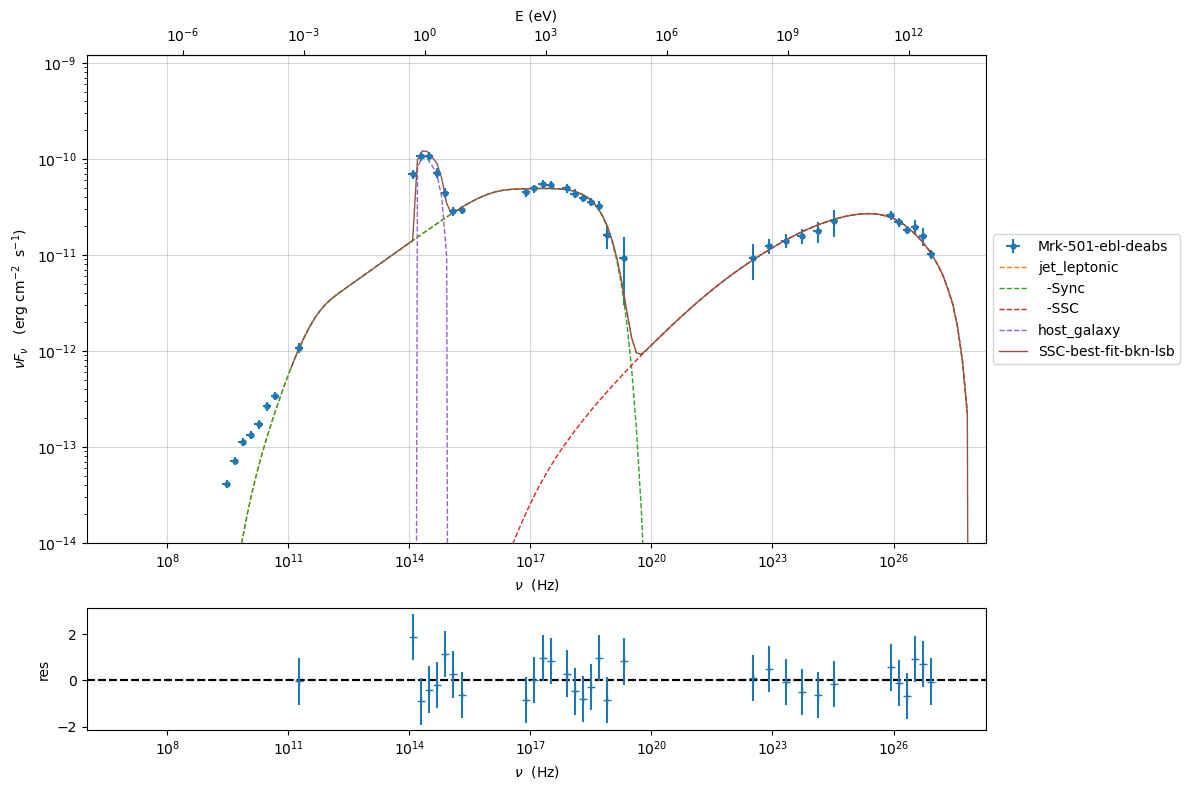

In [27]:
%matplotlib inline
fit_model_bkn.set_nu_grid(1E6,1E30,200)
fit_model_bkn.eval()
p2=fit_model_bkn.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

In [28]:

fit_model_bkn.jet_leptonic.parameters.beam_obj.fit_range=[5,50]
fit_model_bkn.jet_leptonic.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model_bkn.host_galaxy.parameters.nuFnu_p_host.frozen=False
fit_model_bkn.host_galaxy.parameters.nu_scale.frozen=True
fit_model_bkn.jet_leptonic.parameters.gmin.fit_range=[10,1000]
fit_model_bkn.jet_leptonic.parameters.gmax.fit_range=[5E5,1E8]
fit_model_bkn.jet_leptonic.parameters.gamma_break.fit_range=[1E3,1E6]
fit_model_bkn.jet_leptonic.parameters.p.fit_range=[1,3]
fit_model_bkn.jet_leptonic.parameters.p_1.fit_range=[2,5]


model_minimizer_minuit_bkn=ModelMinimizer('minuit')
best_fit_minuit_bkn=model_minimizer_minuit.fit(fit_model_bkn,sed_data,1E11,1E29,fitname='SSC-best-fit-minuit-bkn',repeat=3)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 31

*** start fit process ***
----- 
fit run: 0


0it [00:00, ?it/s]

- best chisq=1.48733e+01

fit run: 1
- old chisq=1.48733e+01


0it [00:00, ?it/s]

- best chisq=1.48728e+01

fit run: 2
- old chisq=1.48728e+01


...


converged=True
calls=3787
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 14.87                      │             Nfcn = 3787              │
│ EDM = 2.42 (Goal: 0.0002)        │            time = 5.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0 │  411.45   │   0.09    │            │            │   10    │  1000   │       │
│ 1 │ par_1 │ 1.7856e6  │ 0.0007e6  │            │            │ 500000  │  1e+08  │       │
│ 2 │ par_2 │  6.55895  │  0.00015  │            │            │    0    │         │       │
│ 3 │ par_3 │  79.17e3  │  0.04e3   │            │            │  1000   │  1e+06  │       │
│ 4 │ par_4 │ 2.446983  │ 0.000030  │            │            │    1    │    3    │       │
│ 5 │ par_5 │  2.9774   │  0.0023   │            │            │    2    │    5    │       │
│ 6 │ par_6 │ 14.149e15 │ 0.004e15  │            │            │3.16228e+15│3.16228e+17│       │
│ 7 │ par_7 │10.7805e-3 │ 0.0022e-3 │            │            │    0    │         │       │
│ 8 │ par_8 │49.9999994 │ 0.0000008 │            │            │    5    │   50    │       │
│ 9 │ par_9 │ -9.96035  │  0.00030  │            │            │-12.1901 │-8.19011 │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=21
chisq=14.868480, chisq/red=0.708023 null hypothesis sig=0.829493

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
jet_leptonic,gmin,4.114511e+02,4.114511e+02,8.548231e-02,--,3.293600e+02,1.000000e+01,1.000000e+03,False
jet_leptonic,gmax,1.785561e+06,1.785561e+06,7.421492e+02,--,1.624709e+06,5.000000e+05,1.000000e+08,False
jet_leptonic,N,6.558950e+00,6.558950e+00,1.528734e-04,--,1.011791e+01,0.000000e+00,--,False
jet_leptonic,gamma_break,7.916658e+04,7.916658e+04,4.037127e+01,--,6.552381e+04,1.000000e+03,1.000000e+06,False
jet_leptonic,p,2.446983e+00,2.446983e+00,2.960642e-05,--,2.401467e+00,1.000000e+00,3.000000e+00,False
jet_leptonic,p_1,2.977385e+00,2.977385e+00,2.352622e-03,--,2.970469e+00,2.000000e+00,5.000000e+00,False
jet_leptonic,R,1.414889e+16,1.414889e+16,3.930474e+12,--,1.157161e+16,3.162278e+15,3.162278e+17,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,1.078050e-02,1.078050e-02,2.166851e-06,--,1.298148e-02,0.000000e+00,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


-------------------------------------------------------------------------




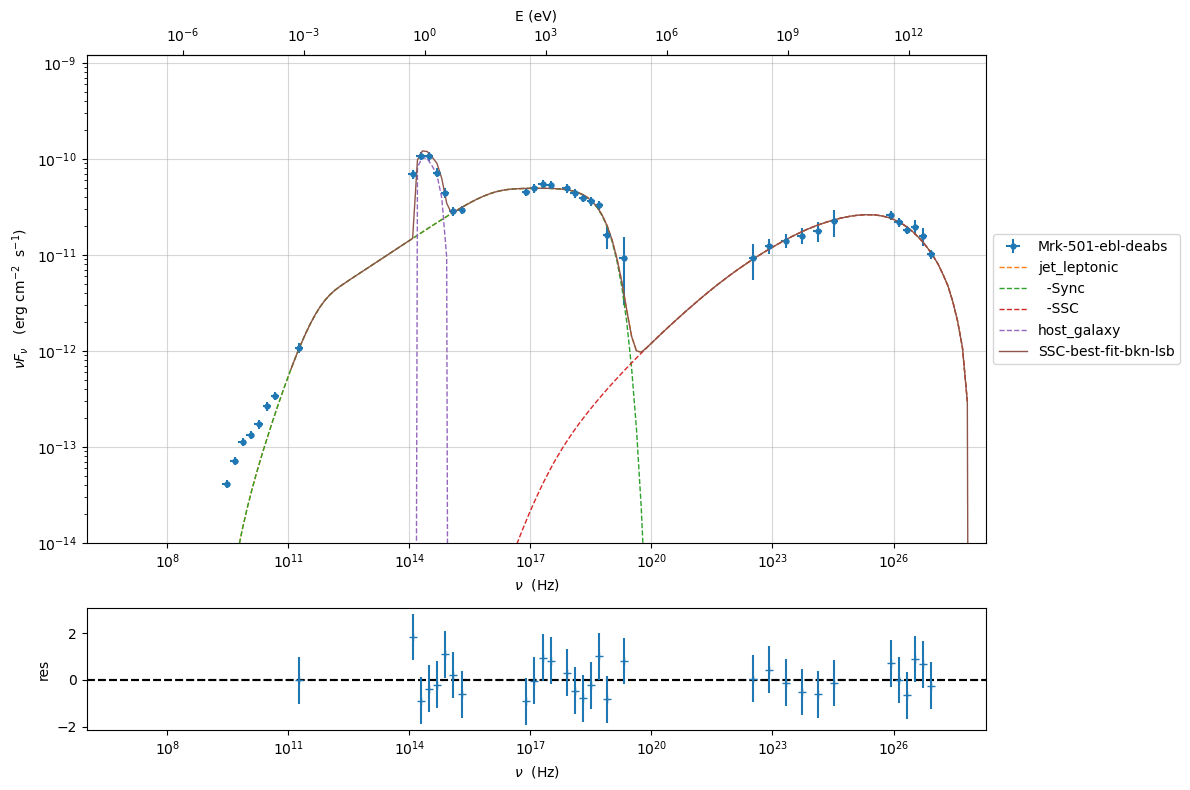

In [29]:
%matplotlib inline
fit_model_bkn.set_nu_grid(1E6,1E30,200)
fit_model_bkn.eval()
p2=fit_model_bkn.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

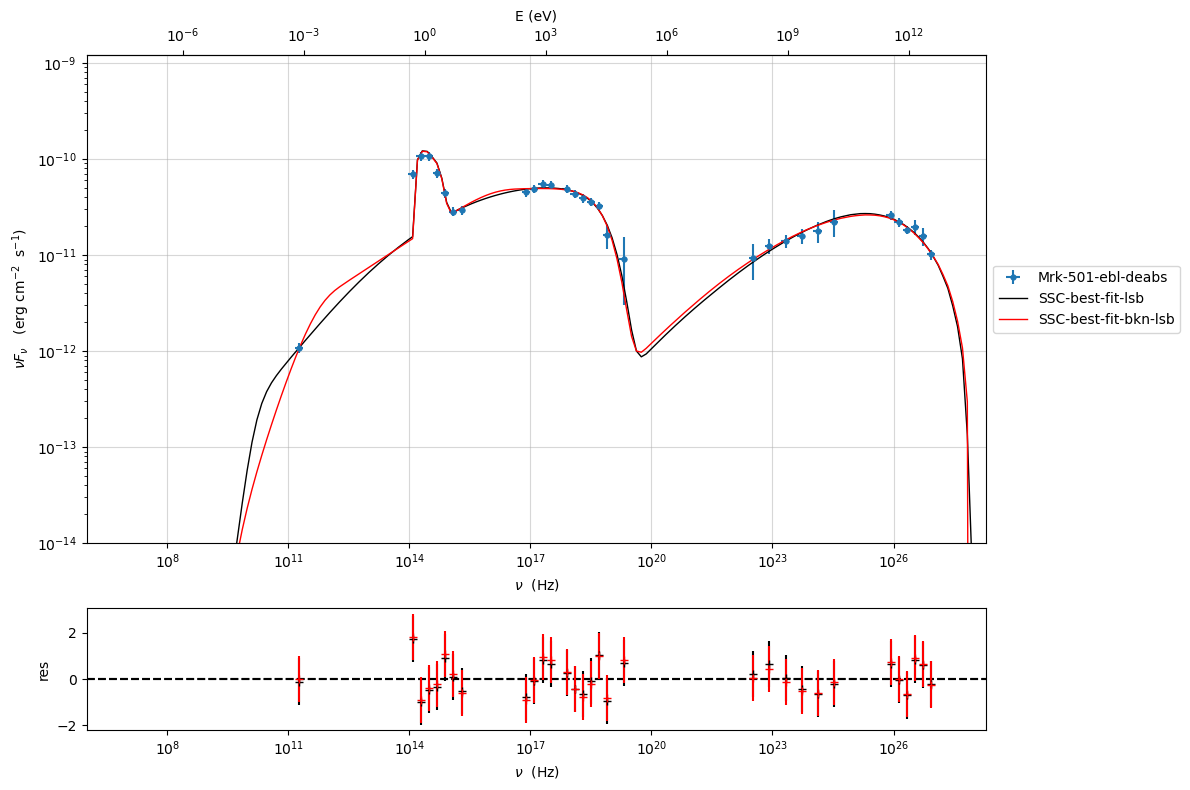

In [30]:
%matplotlib inline
from jetset.plot_sedfit import PlotSED
fit_model_bkn.set_nu_grid(1E6,1E30,200)
fit_model_bkn.eval()
fit_model.set_nu_grid(1E6,1E30,200)
fit_model.eval()

p2=PlotSED()
p2.add_data_plot(sed_data,fit_range=[ 1E11, 1E29])
p2.add_model_plot(fit_model,color='black')
p2.add_residual_plot(fit_model,sed_data,fit_range=[ 1E11, 1E29],color='black')
p2.add_model_plot(fit_model_bkn,color='red')
p2.add_residual_plot(fit_model_bkn,sed_data,fit_range=[ 1E11, 1E29],color='red')
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

## MCMC sampling

### Creating, setting, and running the sampler

In [31]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer


In [32]:
model_minimizer_lsb = ModelMinimizer.load_model('model_minimizer_minuit.pkl')

mcmc=McmcSampler(model_minimizer_lsb)

You can inspect the mcmc parameters using:


In [33]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,9.033414e+01,False,9.033414e+01,--,--,--,1.000000e+01,1.000000e+03,False
jet_leptonic,gmax,2.489652e+06,False,2.489652e+06,--,--,--,5.000000e+05,1.000000e+08,False
jet_leptonic,N,7.466404e+00,False,7.466404e+00,--,--,--,1.000000e-05,1.000000e+05,False
jet_leptonic,gamma0_log_parab,1.025100e+03,False,1.025100e+03,--,--,--,1.000000e+03,5.000000e+05,False
jet_leptonic,s,1.992998e+00,False,1.992998e+00,--,--,--,-1.000000e+01,1.000000e+01,False
jet_leptonic,r,1.830227e-01,False,1.830227e-01,--,--,--,-1.500000e+01,1.500000e+01,False
jet_leptonic,R,3.192345e+16,False,3.192345e+16,--,--,--,3.162278e+15,3.162278e+17,False
jet_leptonic,B,9.197306e-03,False,9.197306e-03,--,--,--,1.000000e-03,1.000000e+00,False
jet_leptonic,beam_obj,3.428535e+01,False,3.428535e+01,--,--,--,5.000000e+00,5.000000e+01,False


In [34]:
mcmc.model.jet_leptonic.parameters.freeze_all()
mcmc.model.host_galaxy.parameters.freeze_all()
mcmc.model.jet_leptonic.parameters.N.free()
mcmc.model.jet_leptonic.parameters.B.free()
mcmc.model.jet_leptonic.parameters.s.free()
mcmc.model.jet_leptonic.parameters.beam_obj.free()
mcmc.model.jet_leptonic.parameters.gamma0_log_parab.free()
mcmc.model.host_galaxy.parameters.nuFnu_p_host.free()


You can set different bounds for all the free parameters with the instruction below. In case you want to preserve the `fit_range` defined in the frequentist minimizer you can pass `preserve_fit_range=True`


In [35]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: N  ref value:  7.466404395214112  mcmc bounds: [1e-05, np.float64(44.79842637128467)]
par: gamma0_log_parab  ref value:  1025.1004311603217  mcmc bounds: [1000.0, np.float64(6150.602586961931)]
par: s  ref value:  1.9929979245296892  mcmc bounds: [np.float64(-7.971991698118757), 10]
par: B  ref value:  0.009197305554840484  mcmc bounds: [0.001, np.float64(0.0551838333290429)]
par: beam_obj  ref value:  34.285347200656574  mcmc bounds: [5.0, 50.0]
par: nuFnu_p_host  ref value:  -9.966823825636622  mcmc bounds: [np.float64(-12.190114433378794), np.float64(-8.190114433378794)]


Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.


In [36]:
mcmc.set_bounds(comp_name='jet_leptonic',par_name='N',par_bounds=[1E-5,10])
mcmc.set_bounds(comp_name='jet_leptonic',par_name='s',par_bounds=[0,3])
mcmc.set_bounds(comp_name='jet_leptonic',par_name='beam_obj',par_bounds=[10,50])

par: N  ref value:  7.466404395214112  mcmc bounds: [1e-05, 10]
par: s  ref value:  1.9929979245296892  mcmc bounds: [0, 3]
par: beam_obj  ref value:  34.285347200656574  mcmc bounds: [10, 50]


In [37]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,N,7.466404e+00,False,7.466404e+00,--,--,--,1.000000e-05,1.000000e+01,False
jet_leptonic,gamma0_log_parab,1.025100e+03,False,1.025100e+03,--,--,--,1.000000e+03,6.150603e+03,False
jet_leptonic,s,1.992998e+00,False,1.992998e+00,--,--,--,0.000000e+00,3.000000e+00,False
jet_leptonic,B,9.197306e-03,False,9.197306e-03,--,--,--,1.000000e-03,5.518383e-02,False
jet_leptonic,beam_obj,3.428535e+01,False,3.428535e+01,--,--,--,1.000000e+01,5.000000e+01,False
host_galaxy,nuFnu_p_host,-9.966824e+00,False,-9.966824e+00,--,--,--,-1.219011e+01,-8.190114e+00,False
jet_leptonic,gmin,9.033414e+01,False,--,--,--,--,1.000000e+01,1.000000e+03,True
jet_leptonic,gmax,2.489652e+06,False,--,--,--,--,5.000000e+05,1.000000e+08,True
jet_leptonic,r,1.830227e-01,False,--,--,--,--,-1.500000e+01,1.500000e+01,True


In [38]:
mcmc.run_sampler(nwalkers=20, burnin=50,steps=500,progress='notebook')

mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 11.75 seconds
----------------------------
MCMC best fit solution
comp: jet_leptonic par: N  mcmc best fit val: 7.5715523415336765 quantiles(0.16,0.5,0.84): [7.12272901 7.90902584 8.8451836 ] 
comp: jet_leptonic par: gamma0_log_parab  mcmc best fit val: 1038.7648537976295 quantiles(0.16,0.5,0.84): [1052.27726136 1216.3914807  1629.01564766] 
comp: jet_leptonic par: s  mcmc best fit val: 1.997800140571834 quantiles(0.16,0.5,0.84): [1.99185588 2.02249391 2.06107849] 
comp: jet_leptonic par: B  mcmc best fit val: 0.00914314578546726 quantiles(0.16,0.5,0.84): [0.00838607 0.00944825 0.01072319] 
comp: jet_leptonic par: beam_obj  mcmc best fit val: 34.50251820127597 quantiles(0.16,0.5,0.84): [31.18402882 33.6226433  35.80000713] 
comp: host_galaxy par: nuFnu_p_host  mcmc best fit val: -9.972867989897034 quantiles(0.16,0.5,0.84): [-9.99404332 -9.96142346 -9.92963697] 
----------------------------


In [39]:
print(mcmc.acceptance_fraction)

0.3945


### post-run tuning of the burnin
We plot the chains, before and after, tuning the burnin (using autocorrelation time of emcee).

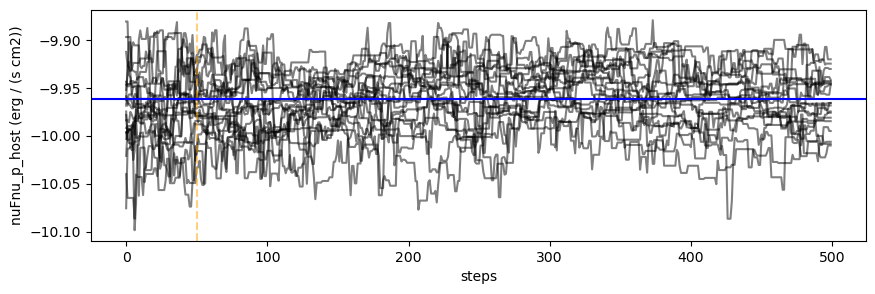

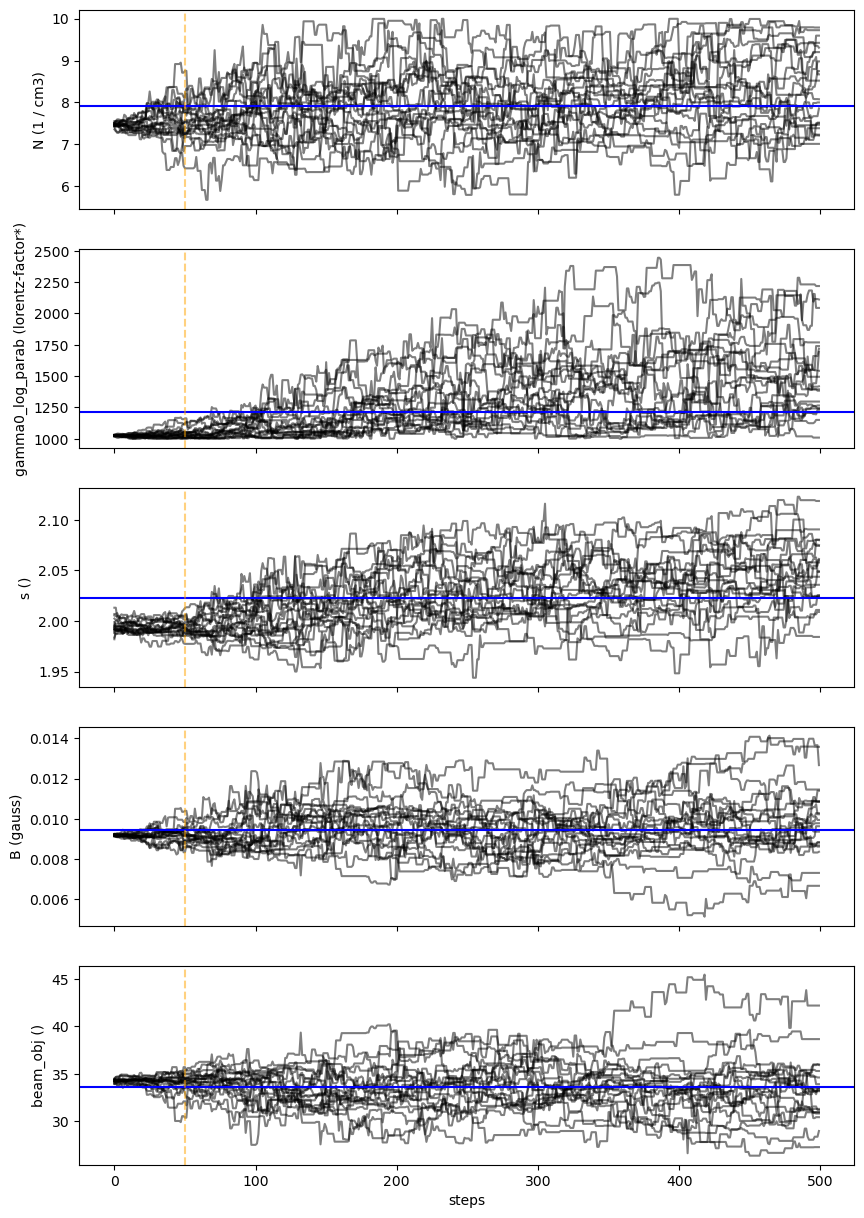

In [40]:
p=mcmc.plot_chain()

----------------------------
MCMC best fit solution
comp: jet_leptonic par: N  mcmc best fit val: 7.4398533009215875 quantiles(0.16,0.5,0.84): [7.11985382 7.97166899 8.95271213] 
comp: jet_leptonic par: gamma0_log_parab  mcmc best fit val: 1093.256669579238 quantiles(0.16,0.5,0.84): [1077.71490804 1277.14411088 1665.17053688] 
comp: jet_leptonic par: s  mcmc best fit val: 2.001638126163022 quantiles(0.16,0.5,0.84): [1.9983149  2.02788919 2.06610169] 
comp: jet_leptonic par: B  mcmc best fit val: 0.009214368515703848 quantiles(0.16,0.5,0.84): [0.00831426 0.00954747 0.01084583] 
comp: jet_leptonic par: beam_obj  mcmc best fit val: 34.37346610986755 quantiles(0.16,0.5,0.84): [31.0311124  33.49126246 35.98738266] 
comp: host_galaxy par: nuFnu_p_host  mcmc best fit val: -9.978156219250845 quantiles(0.16,0.5,0.84): [-9.99228053 -9.96006365 -9.92930441] 
----------------------------


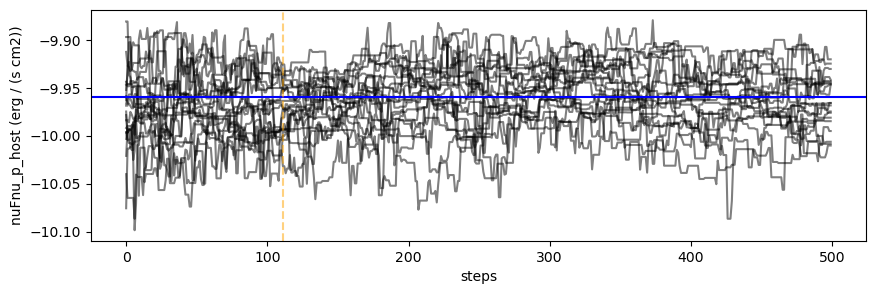

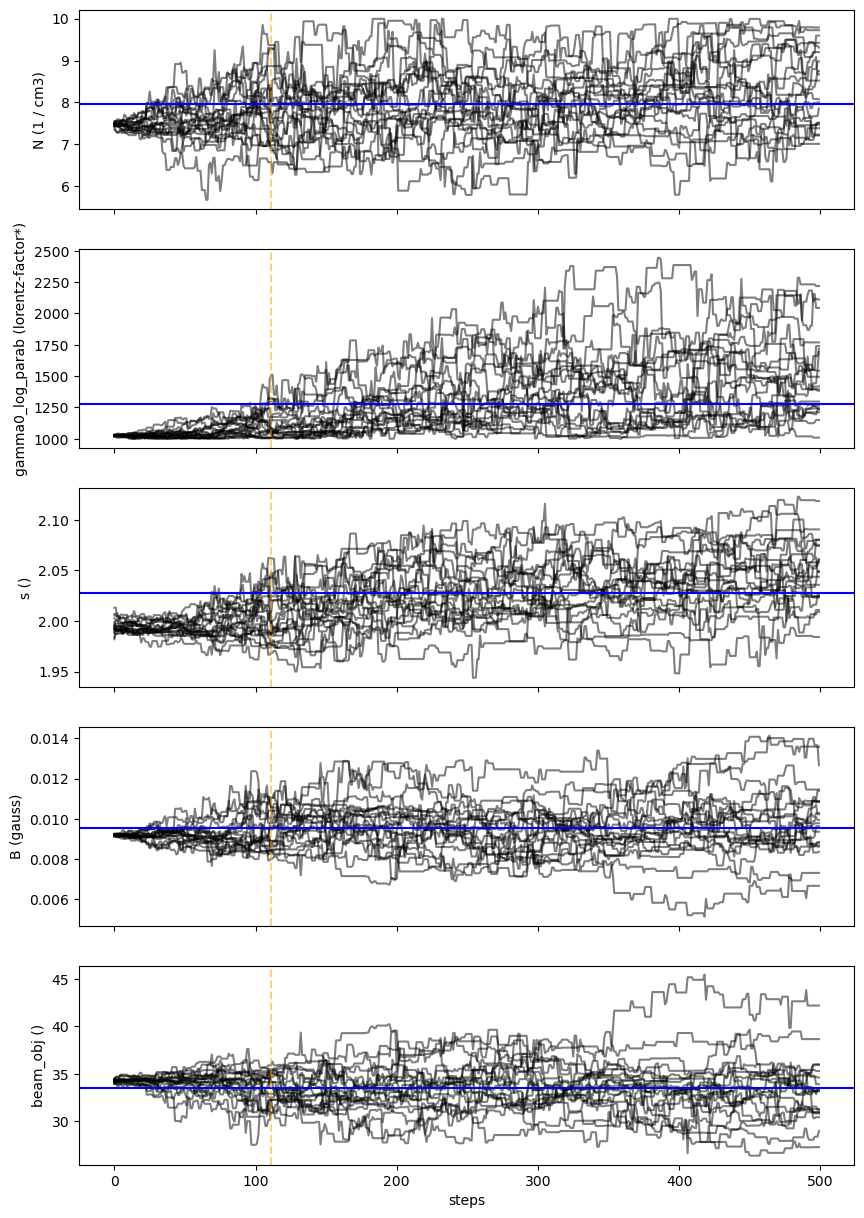

In [41]:
mcmc.tune_burnin(tau_coeff=2)
p=mcmc.plot_chain()

The updated burnin value has increased compared to the initial one, now the chain samples a parameter space closer to the convergence.

### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [42]:
mcmc.set_plot_label('N',r'$N$',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'$B$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')
mcmc.set_plot_label('s',r'$s$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma0_log_parab',r'$\gamma_0$',comp_name='jet_leptonic')
mcmc.set_plot_label('nuFnu_p_host',r'$\nu F_{\nu_p} {\rm host}$',comp_name='host_galaxy')

the code below lets you tuning the output:

 1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
 2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
 3) title_kwargs=dict(fontsize=12) you can change the fontsize


Per-component corner plot

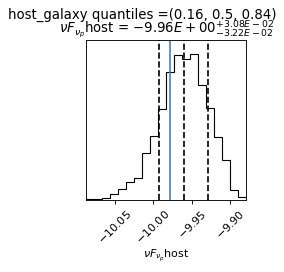

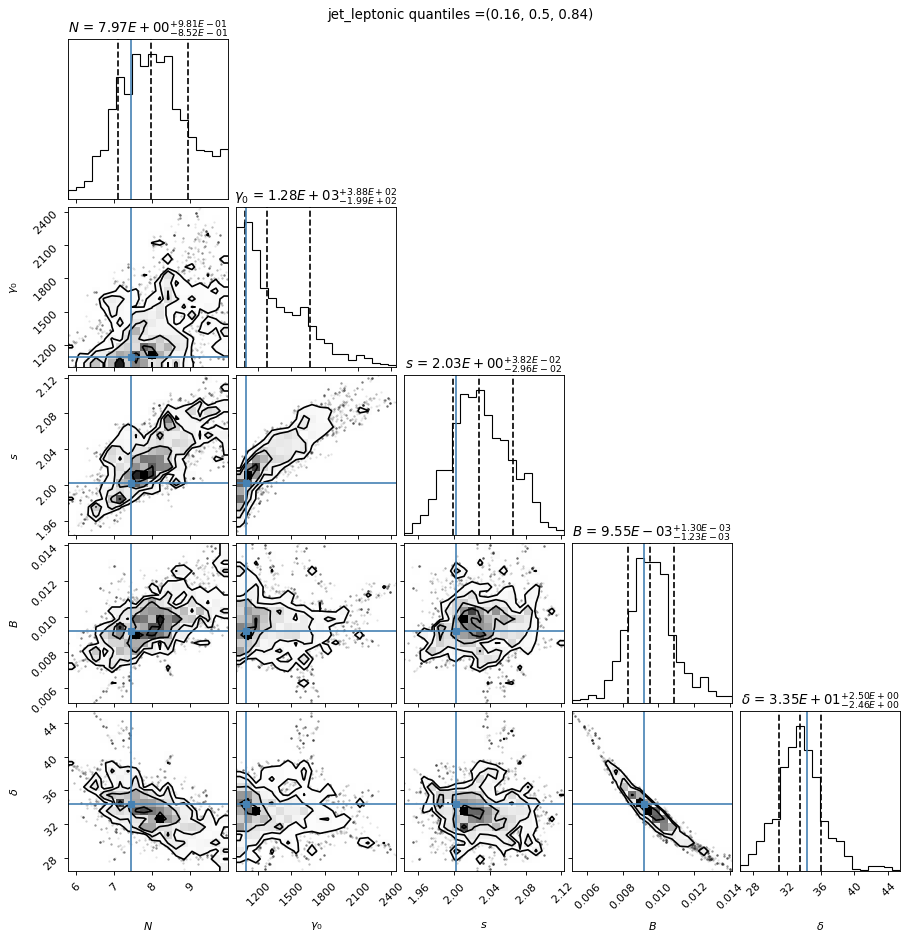

In [43]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


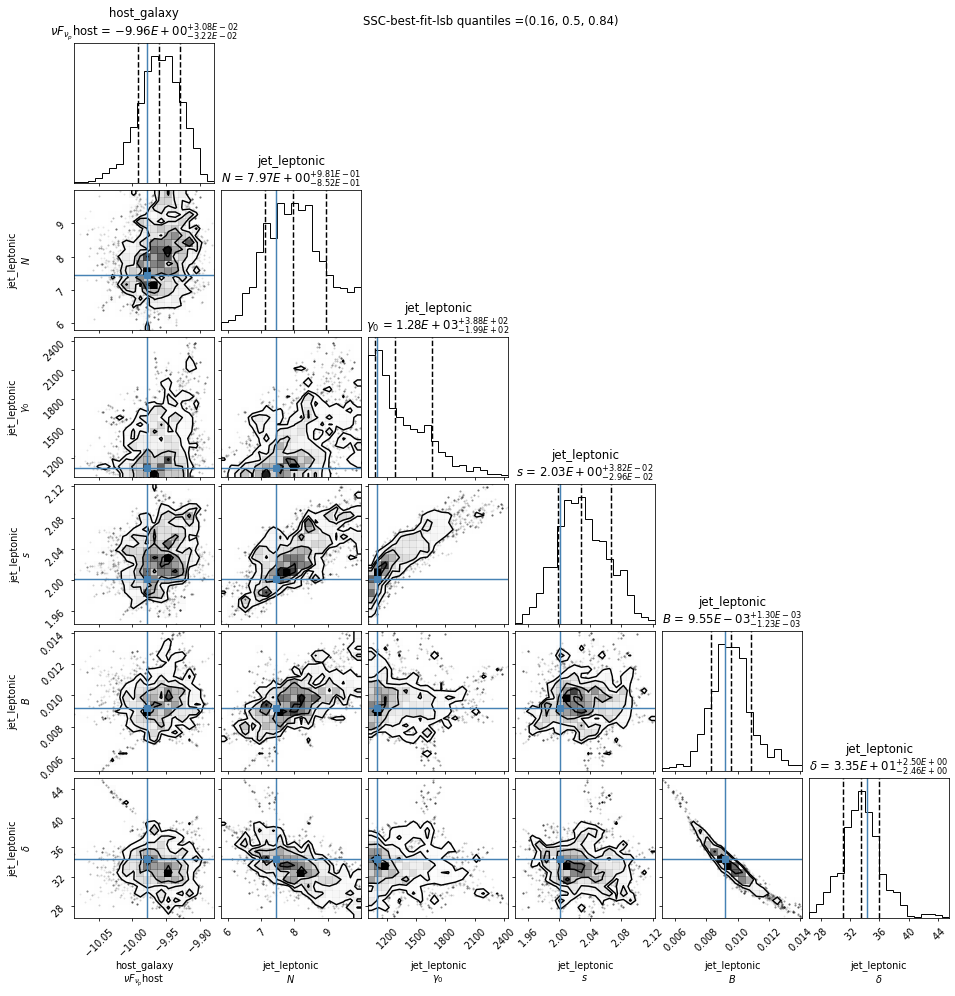

In [44]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

### plotting the model

To plot the sampled model range against the  mcmc best-fit model


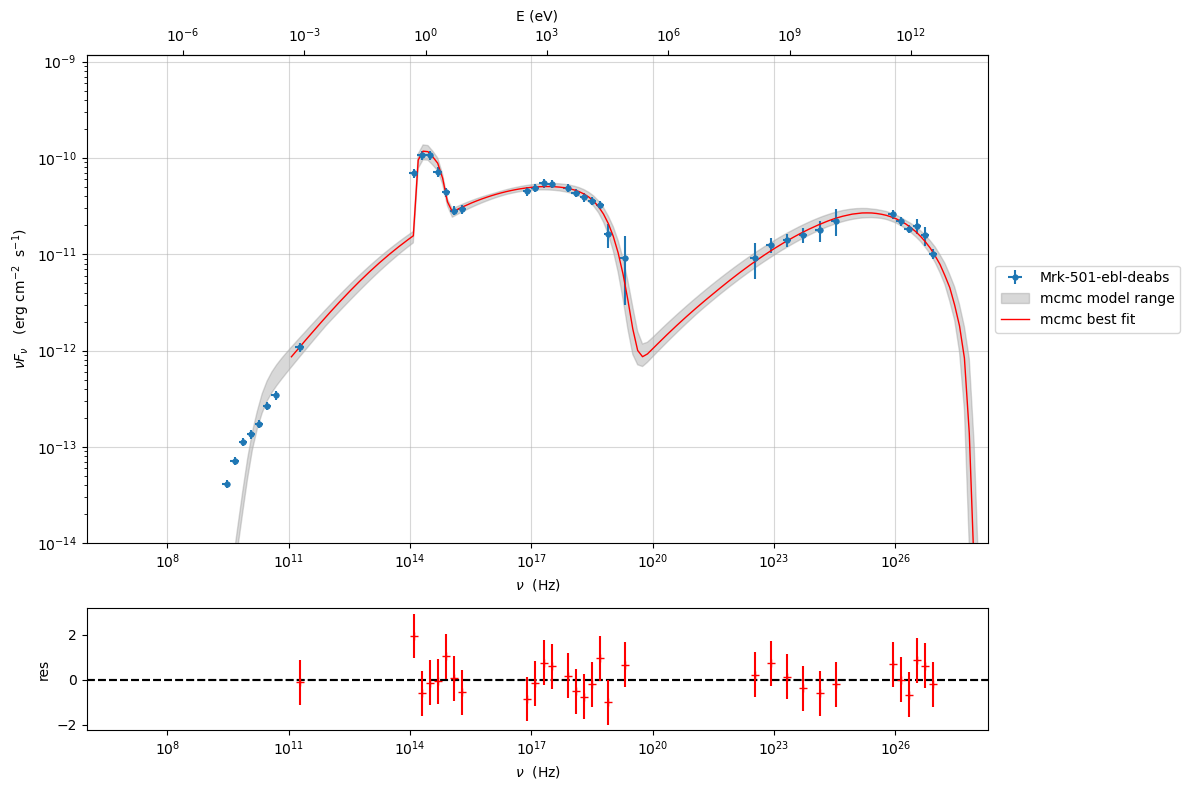

In [45]:

from jetset.data_loader import ObsData
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

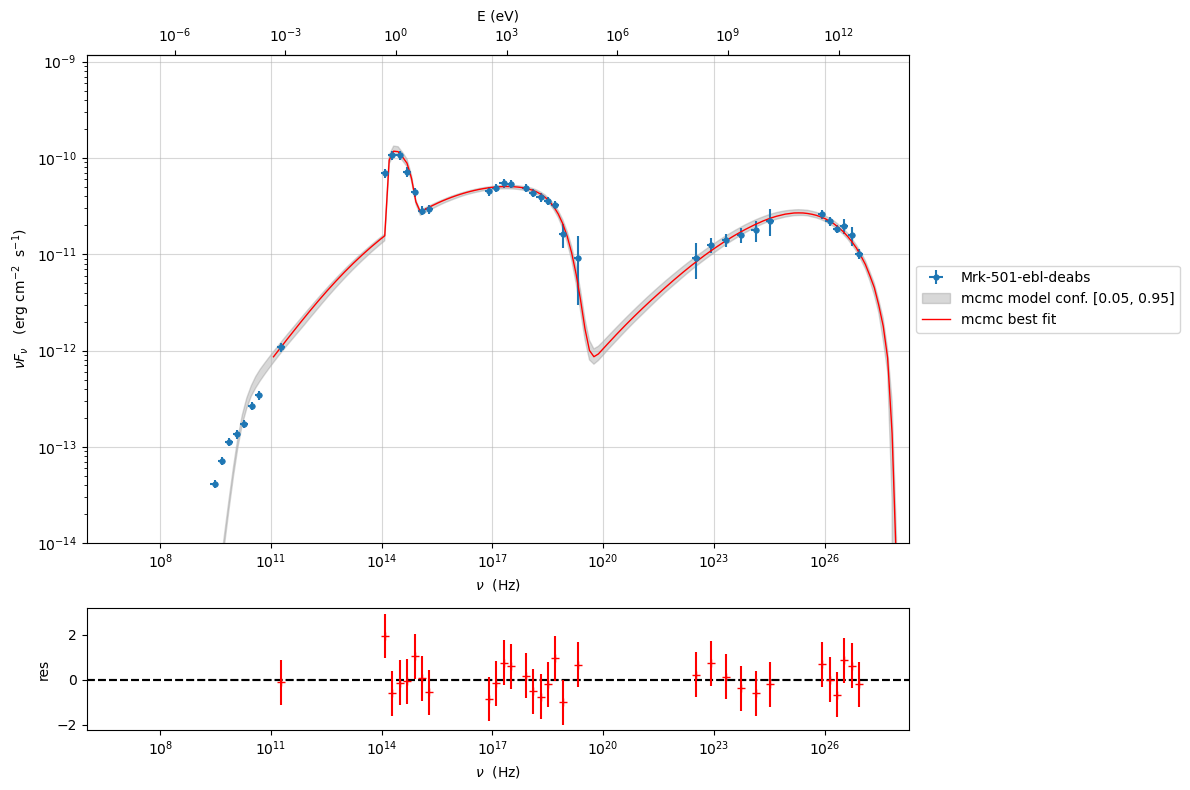

In [46]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

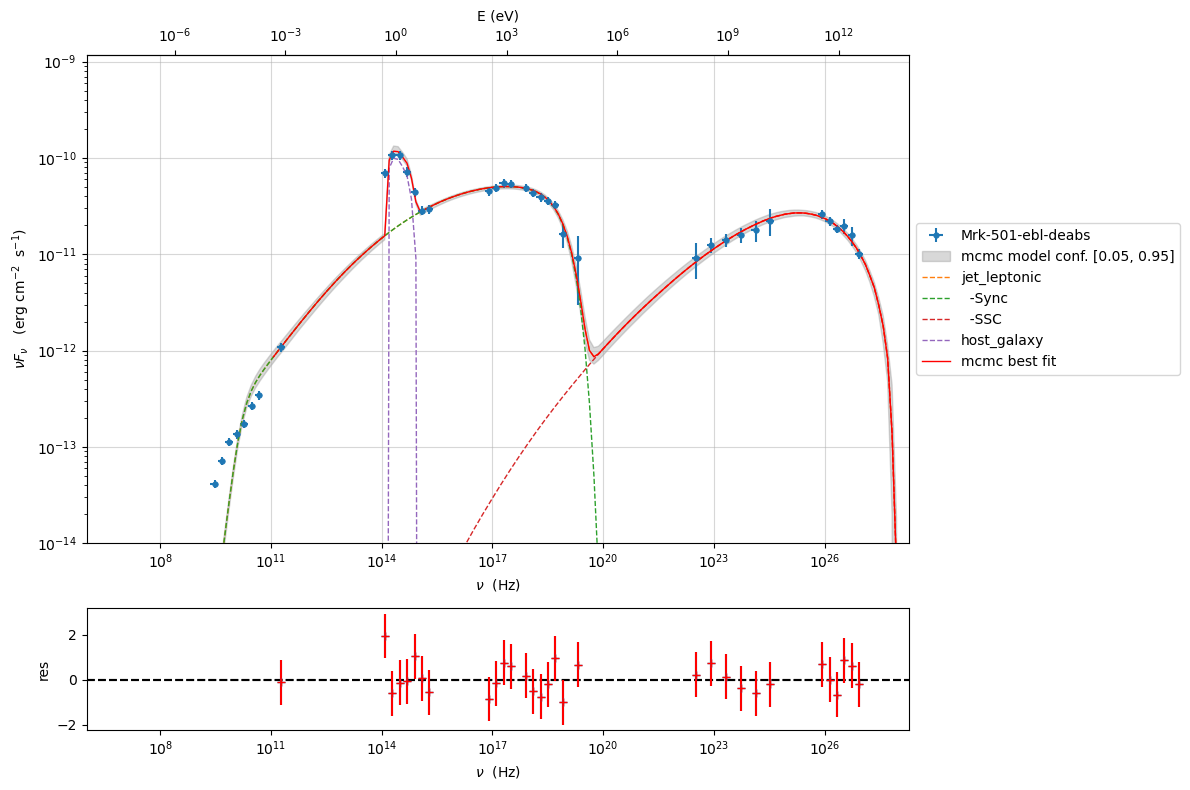

In [47]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model==False``)

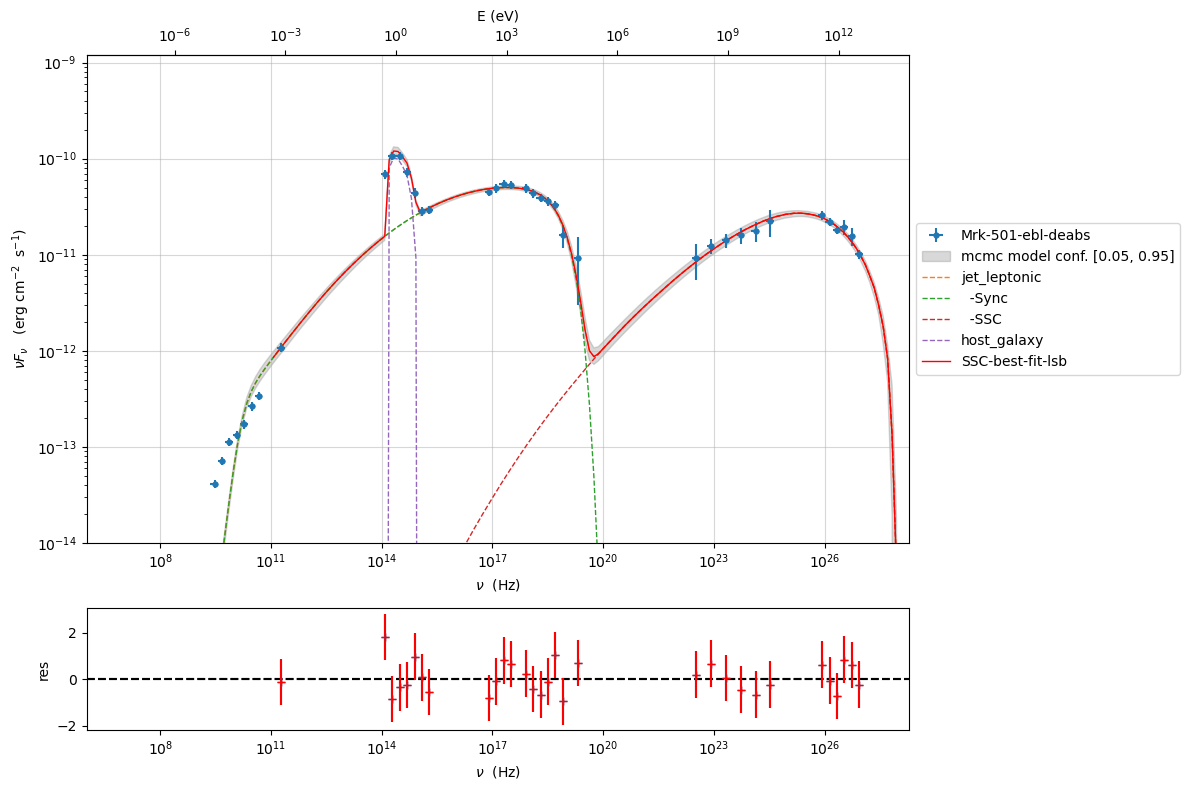

In [48]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

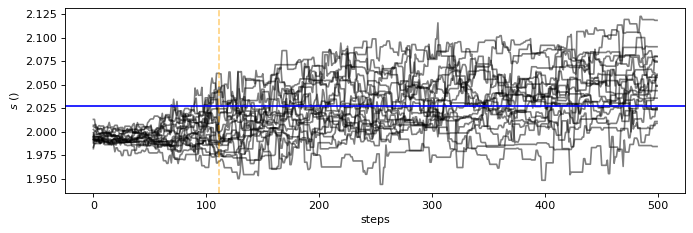

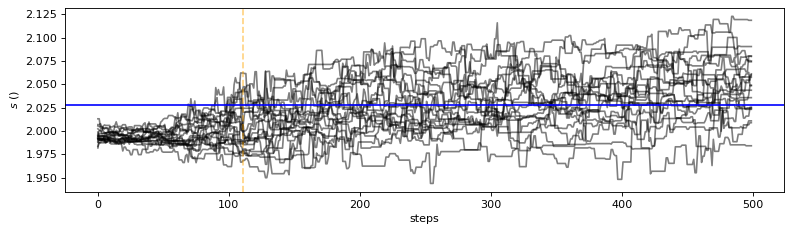

In [49]:
import matplotlib.pylab as plt

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='s',log_plot=False)
plt.tight_layout()

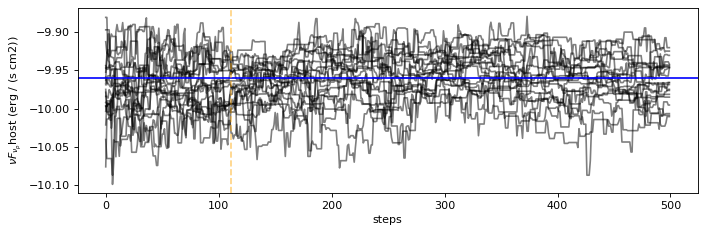

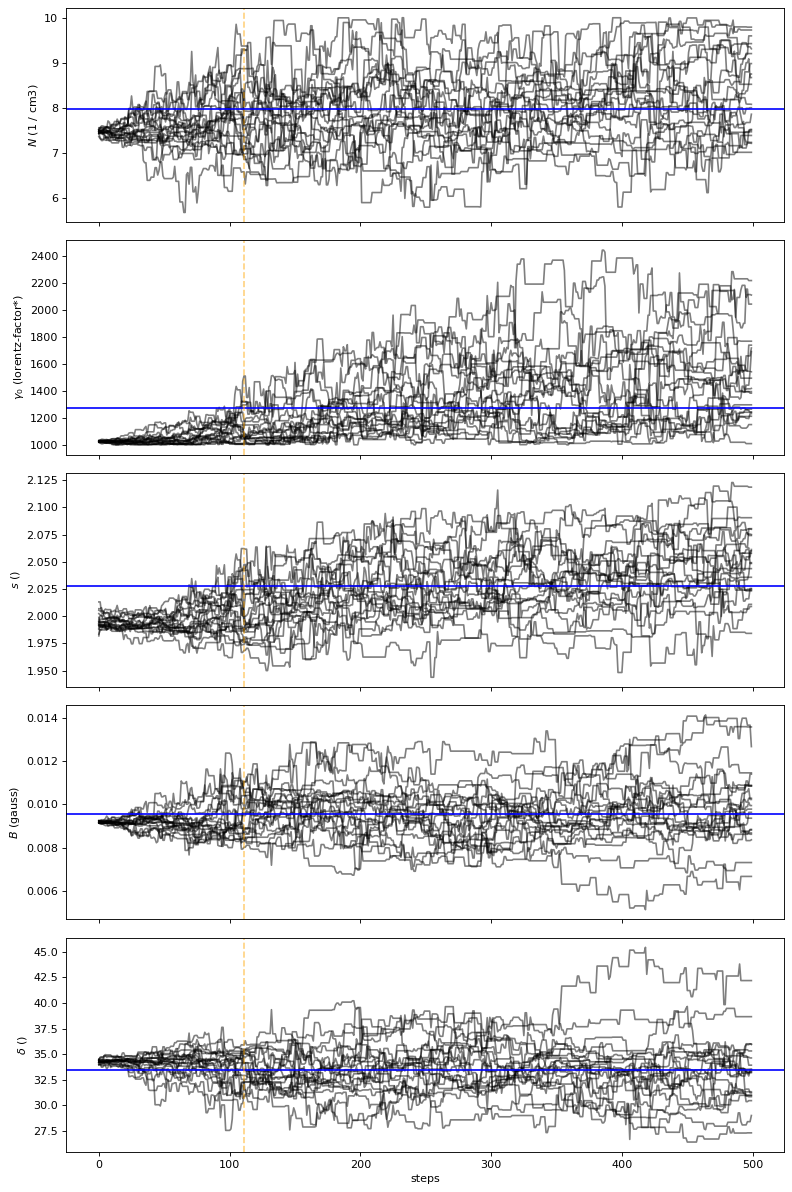

In [50]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

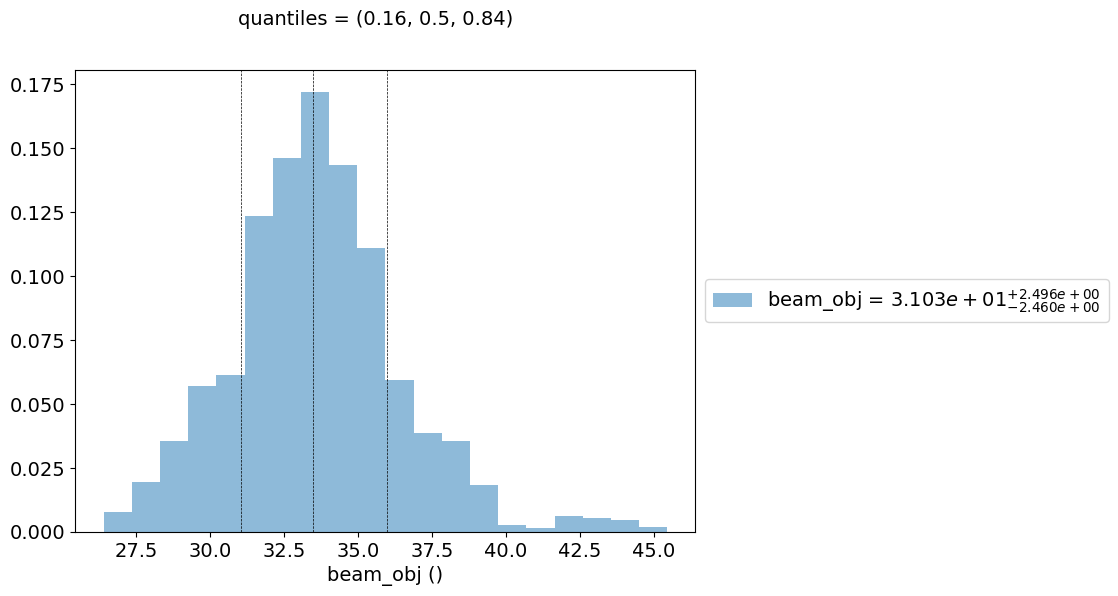

In [51]:

f=mcmc.plot_par('beam_obj',figsize=(8,6))
mpl.rcParams['figure.dpi'] = 80

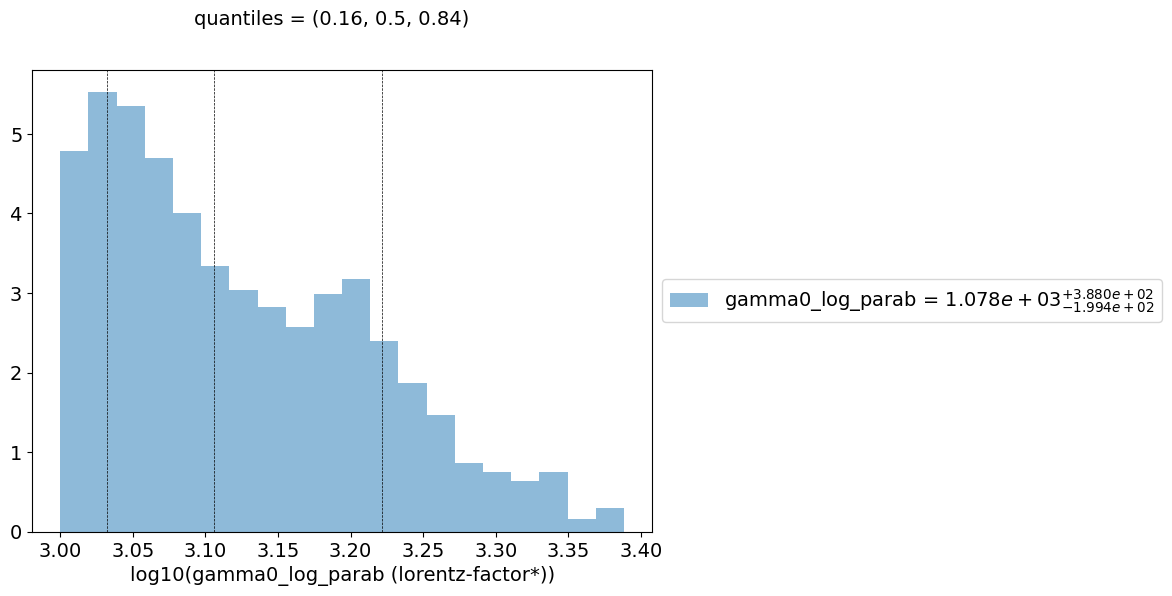

In [52]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_par('gamma0_log_parab',log_plot=True,figsize=(8,6))

## Save and reuse MCMC

In [53]:
mcmc.save('mcmc_sampler.pkl')

In [54]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_501.pkl')
ms=McmcSampler.load('mcmc_sampler.pkl')

import matplotlib as mpl


In [55]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,N,7.439853e+00,False,7.439853e+00,7.119854e+00,7.971669e+00,8.952712e+00,1.000000e-05,1.000000e+01,False
jet_leptonic,gamma0_log_parab,1.093257e+03,False,1.093257e+03,1.077715e+03,1.277144e+03,1.665171e+03,1.000000e+03,6.150603e+03,False
jet_leptonic,s,2.001638e+00,False,2.001638e+00,1.998315e+00,2.027889e+00,2.066102e+00,0.000000e+00,3.000000e+00,False
jet_leptonic,B,9.214369e-03,False,9.214369e-03,8.314260e-03,9.547473e-03,1.084583e-02,1.000000e-03,5.518383e-02,False
jet_leptonic,beam_obj,3.437347e+01,False,3.437347e+01,3.103111e+01,3.349126e+01,3.598738e+01,1.000000e+01,5.000000e+01,False
host_galaxy,nuFnu_p_host,-9.978156e+00,False,-9.978156e+00,-9.992281e+00,-9.960064e+00,-9.929304e+00,-1.219011e+01,-8.190114e+00,False
jet_leptonic,gmin,9.033414e+01,False,--,--,--,--,1.000000e+01,1.000000e+03,True
jet_leptonic,gmax,2.489652e+06,False,--,--,--,--,5.000000e+05,1.000000e+08,True
jet_leptonic,r,1.830227e-01,False,--,--,--,--,-1.500000e+01,1.500000e+01,True


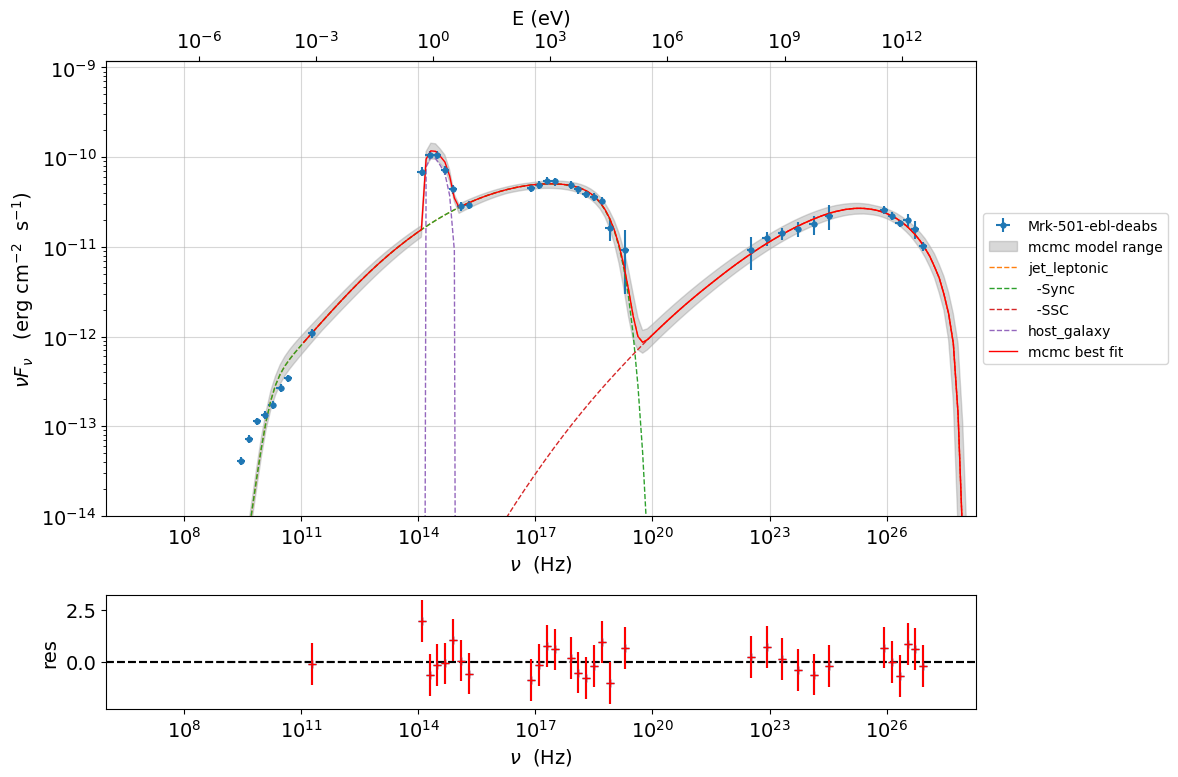

In [56]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

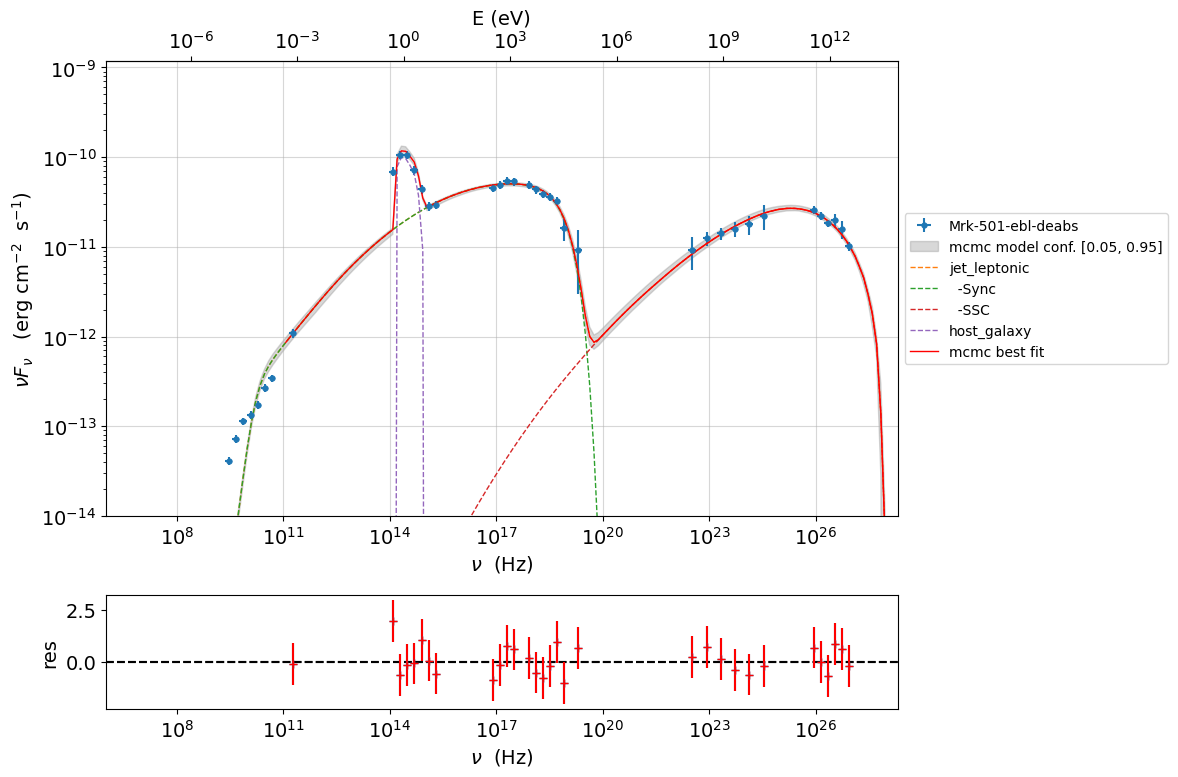

In [57]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

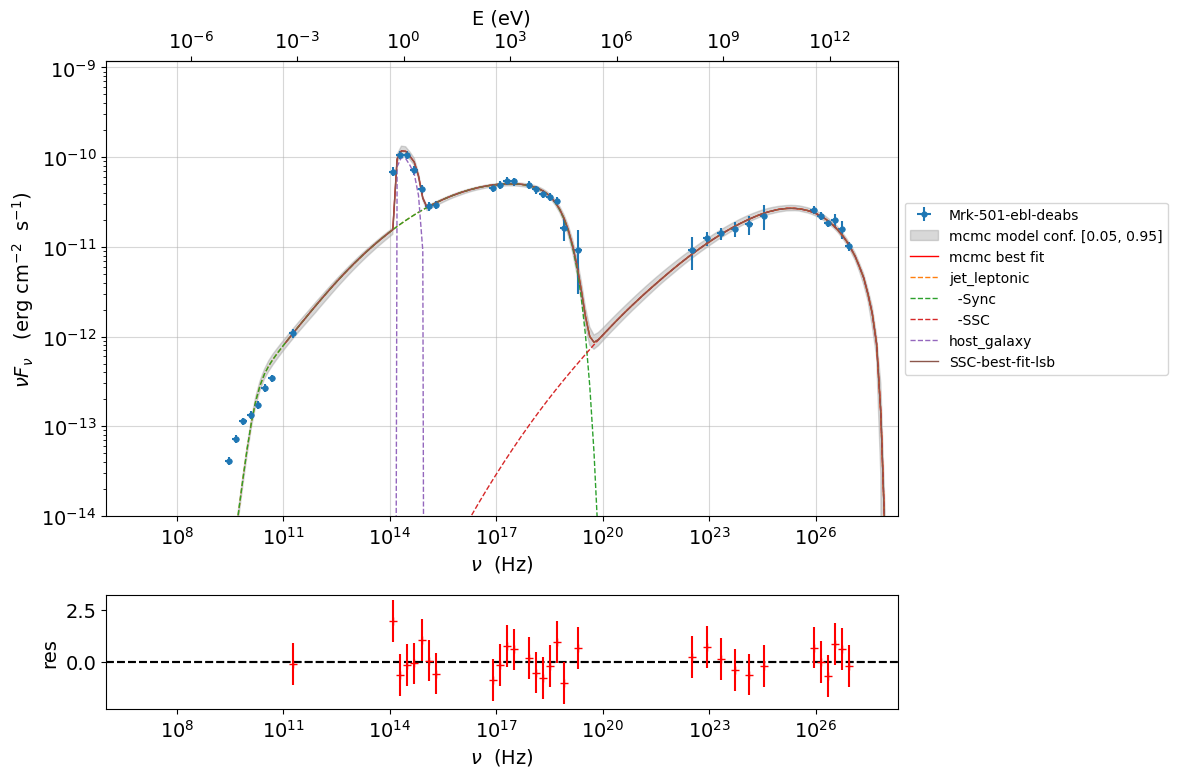

In [58]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

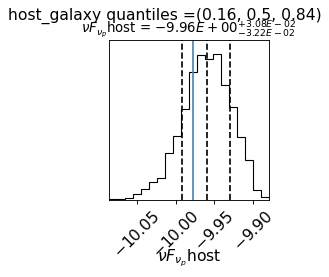

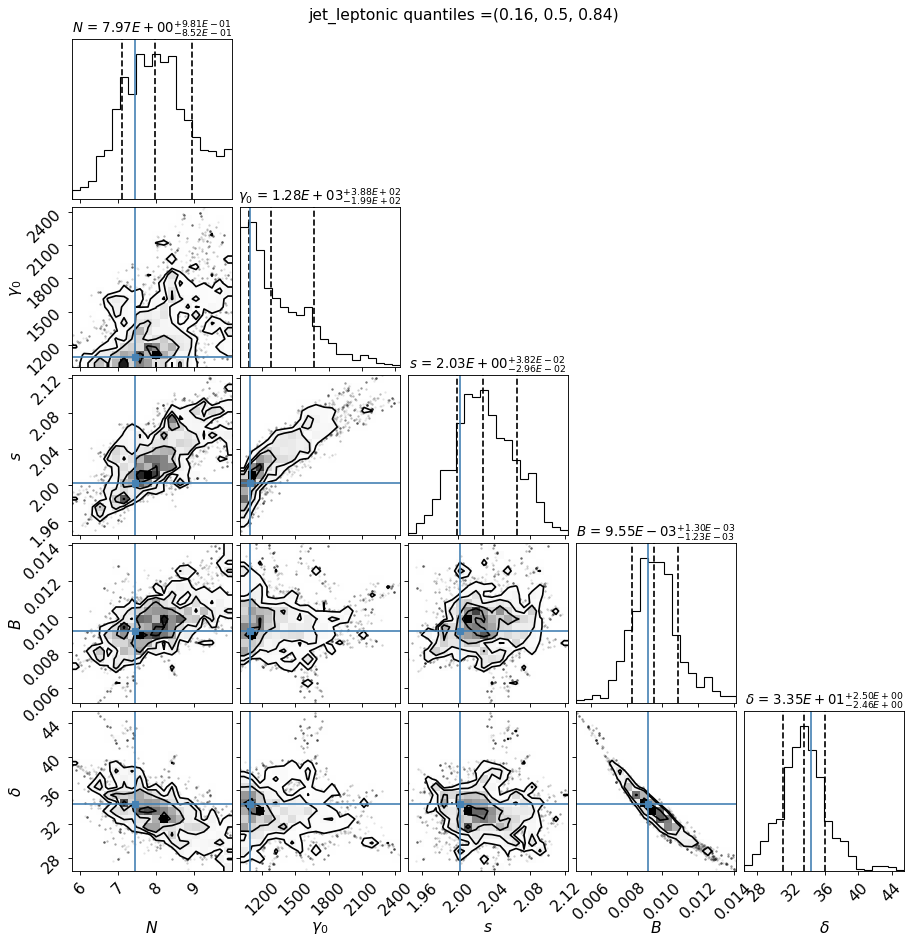

In [59]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


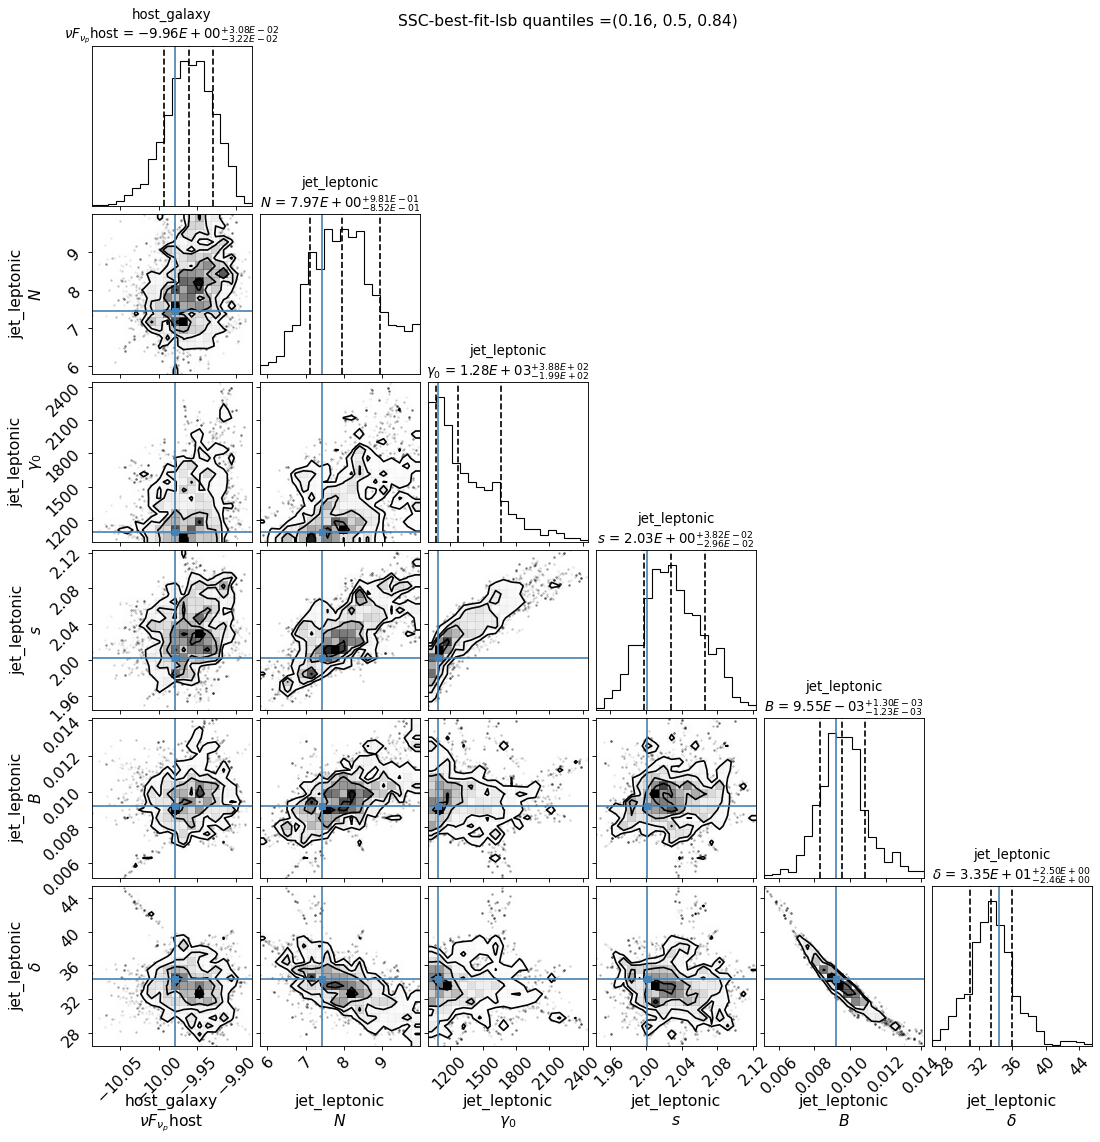

In [60]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

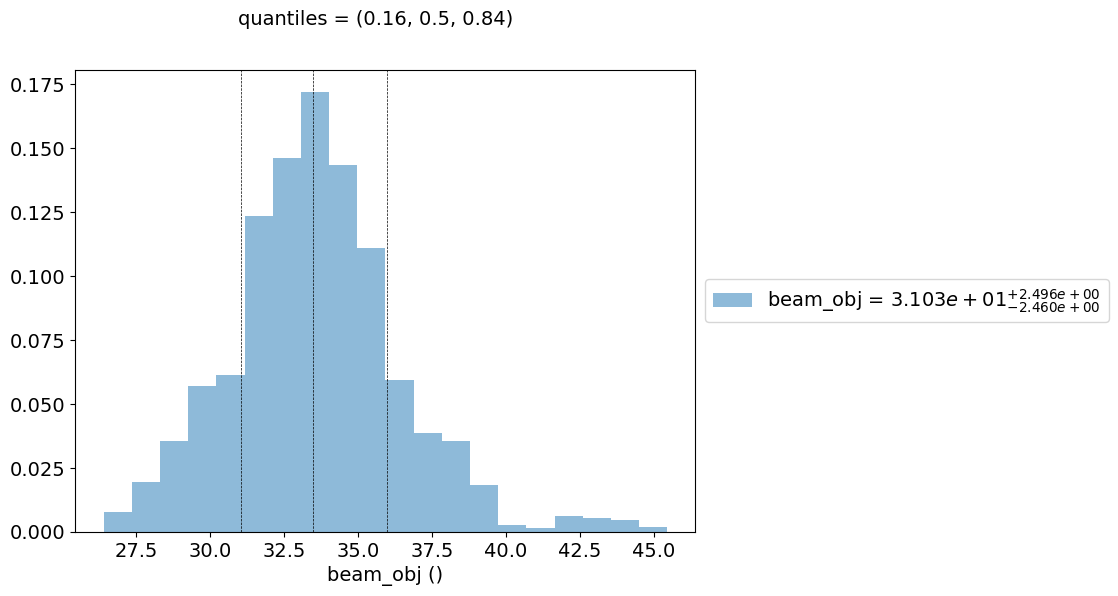

In [61]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_par('beam_obj',log_plot=False,figsize=(8,6))

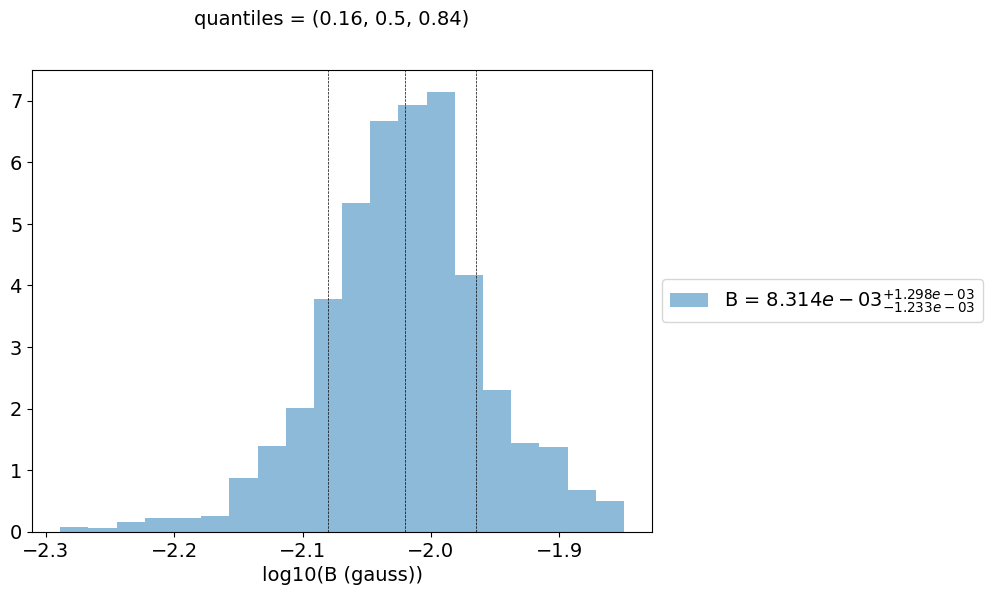

In [62]:
f=ms.plot_par('B',log_plot=True,figsize=(8,6))

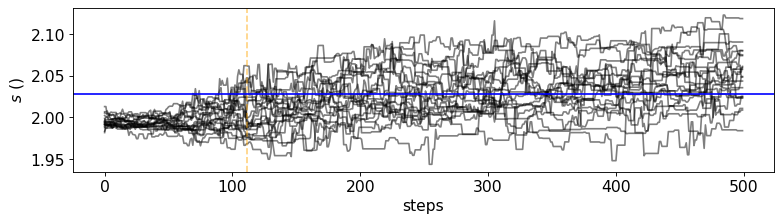

In [63]:
from matplotlib import pylab as plt
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_chain(par_name='s',comp_name='jet_leptonic',log_plot=False)
plt.tight_layout()

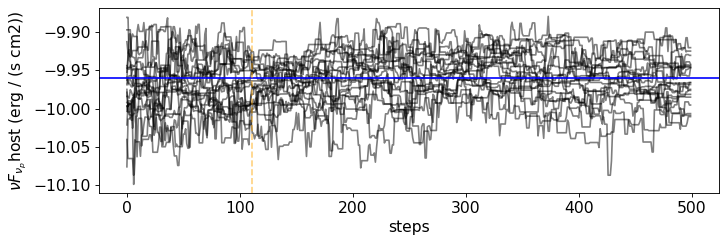

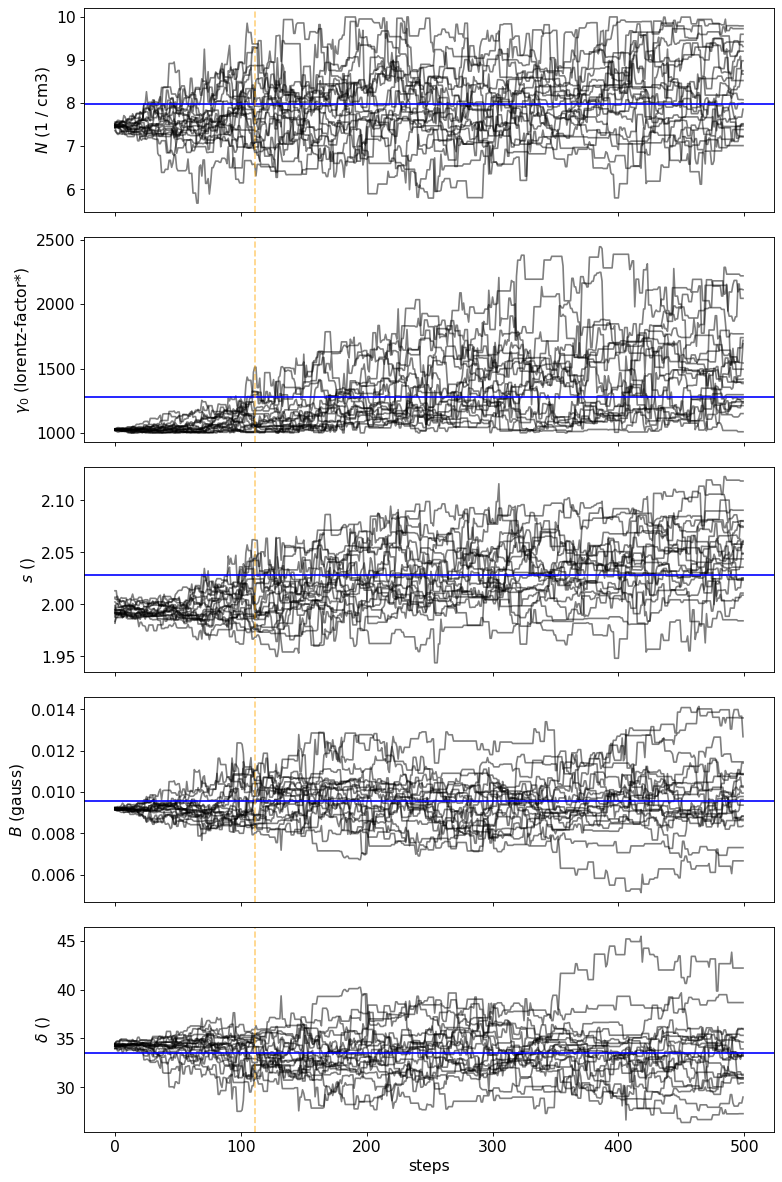

In [64]:
f=ms.plot_chain(log_plot=False)
plt.tight_layout()
mpl.rcParams['figure.dpi'] = 80